<a href="https://colab.research.google.com/github/sflj-cin/ia-Industrial/blob/main/motor_fault_monitoring_poc_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Manutenção Preditiva com Sinais Vibro-Acústicos
## Desafio IA Industrial — SENAI/PE Cód. 164 (Pesquisador Industrial II)

**Dataset:** subset do *University of Ottawa Electric Motor Dataset* — Vibration and
Acoustic Faults under Constant and Variable Speed Conditions (UOEMD-VAFCVS)
(SEHRI; DUMOND; BOUCHARD, 2024), licença CC-BY 4.0.

**Ambiente:** Google Colab (Python 3.10+). Este notebook é autocontido: instala suas
próprias dependências e pede upload do dataset — não depende de nenhum pacote externo
ao Colab.

---

### Estrutura

| Seção | Conteúdo |
|---|---|
| 0 | Setup: dependências e carregamento dos dados |
| 1 | Metadados e checagem de integridade |
| 2 | EDA — domínio do tempo (indicadores estatísticos) |
| 3 | EDA — domínio da frequência (PSD de Welch, order tracking, 15Hz×45Hz) |
| 4 | Engenharia de features (tempo + frequência + correlação cruzada entre sensores) |
| 5 | Estratégia de validação (leave-one-condition-out, sem vazamento) |
| 6 | Diagnóstico quantificado do impacto do vazamento de dados |
| 7 | Classificação — Random Forest × XGBoost |
| 8 | Avaliação, matrizes de confusão, importância de features |
| 9 | Módulo 2 (bônus) — softsensor de temperatura, com HPO aninhado (Optuna) |
| 10 | Conclusões, limitações e evolução para produção |
| 11 | Referências (ABNT) |

**Convenção de citação:** cada afirmação técnica não trivial traz uma referência no
formato ABNT (SOBRENOME, ano) apontando para a literatura ou norma que a sustenta. A
lista completa, com as referências completas, está na Seção 11.


## 0. Setup e carregamento dos dados

In [ ]:
# ── Instalação de dependências ────────────────────────────────────────────────
# scipy.signal.welch (PEDREGOSA et al., 2011; VIRTANEN et al., 2020) para PSD;
# scikit-learn para os modelos e métricas; xgboost para o segundo classificador
# (CHEN; GUESTRIN, 2016); optuna para otimização de hiperparâmetros com o
# amostrador TPE (AKIBA et al., 2019).
import subprocess, sys

required = ["numpy", "pandas", "scipy", "scikit-learn", "xgboost",
            "matplotlib", "seaborn", "optuna", "pyarrow"]
for pkg in required:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("Dependencias instaladas.")


Dependencias instaladas.


In [ ]:
# ── Imports globais ────────────────────────────────────────────────────────────
import json
import os
import re
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.signal as sig
from scipy.stats import kurtosis, skew
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_fscore_support, mean_absolute_error, r2_score,
)
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
})
sns.set_style("whitegrid")

RNG_SEED = 42
np.random.seed(RNG_SEED)

print(f"NumPy {np.__version__} | Pandas {pd.__version__} | SciPy {sig.__name__} | "
      f"Optuna {optuna.__version__}")


NumPy 2.1.3 | Pandas 2.2.3 | SciPy scipy.signal | Optuna 4.9.0


### Carregamento do dataset

O dataset (16 arquivos CSV, ~310 MB) deve ser enviado como um único `.zip` contendo os
16 CSVs na raiz (ou em uma subpasta). Em ambiente Colab, a célula abaixo abre o
seletor de upload automaticamente. Fora do Colab (ex.: execução local para
desenvolvimento), ela procura uma pasta `data/` já existente.

In [ ]:
# ── Carregamento dos dados (Colab: upload via ZIP; local: pasta ja existente) ──
import zipfile

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = None

if IN_COLAB:
    ZIP_PATH = "dataset_desafio.zip"
    DATA_ROOT = Path("dataset")
    if not DATA_ROOT.exists():
        if not Path(ZIP_PATH).exists():
            print(f"Faca upload do arquivo '{ZIP_PATH}' (ou ajuste ZIP_PATH abaixo)...")
            uploaded = files.upload()
            # se o nome enviado for diferente, usa o primeiro .zip recebido
            zip_candidates = [f for f in uploaded if f.endswith(".zip")]
            if zip_candidates:
                ZIP_PATH = zip_candidates[0]
        DATA_ROOT.mkdir(exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH) as zf:
            zf.extractall(DATA_ROOT)
    # localiza a pasta que efetivamente contem os CSVs
    csv_dirs = [p.parent for p in DATA_ROOT.rglob("*.csv")]
    DATA_DIR = str(csv_dirs[0]) if csv_dirs else str(DATA_ROOT)
else:
    DATA_DIR = "data"

n_csv = len(list(Path(DATA_DIR).glob("*.csv")))
print(f"DATA_DIR = '{DATA_DIR}' ({n_csv} arquivos CSV encontrados)")
assert n_csv == 16, f"Esperados 16 arquivos CSV, encontrados {n_csv}. Verifique DATA_DIR."


Faca upload do arquivo 'dataset_desafio.zip' (ou ajuste ZIP_PATH abaixo)...


Saving dataset_desafio.zip to dataset_desafio.zip
DATA_DIR = 'dataset' (16 arquivos CSV encontrados)


## 1. Metadados e checagem de integridade

Convenção de nomenclatura do dataset: `{Letra1}_{Letra2}_{Velocidade}_{Carga}.csv`,
onde a velocidade codifica a frequência nominal de comando do VFD (1→15 Hz, 3→45 Hz) e
a carga o estado do disco de carga (0→sem carga, 1→com carga). Cada arquivo contém
420.000 amostras × 5 colunas, adquiridas a $F_s = 42\,000$ Hz durante 10 s
(SEHRI; DUMOND; BOUCHARD, 2024).

A taxa de amostragem de 42 kHz decorre do critério de Nyquist-Shannon aplicado ao
limite do espectro audível (~20 kHz): para reconstruir um sinal sem *aliasing*, é
necessário amostrar a uma frequência $F_s > 2 f_{max}$ (NYQUIST, 1928; SHANNON, 1949).
A frequência de Nyquist deste dataset é, portanto,
$$f_{Nyquist} = F_s/2 = 21\,000 \text{ Hz}.$$

In [ ]:
FS = 42_000          # Hz - taxa de amostragem
WIN_SIZE = FS         # 1 segundo por janela (42.000 amostras)
N_SAMPLES = 420_000   # amostras por arquivo
DURATION = 10         # segundos

COLS = {
    "accel1": "Accelerometer 1 (m/s^2)",   # drive-end - ruidoso (VFD)
    "mic":    "Microphone (V)",
    "accel2": "Accelerometer 2 (m/s^2)",   # eixo - limpo
    "accel3": "Accelerometer 3 (m/s^2)",   # eixo - limpo
    "temp":   "Temperature (Celsius)",
}
VIB_COLS = ["accel1", "accel2", "accel3"]
CLEAN_VIB = ["accel2", "accel3"]           # canais sem ruido eletrico do inversor
ALL_SENS = ["accel1", "accel2", "accel3", "mic"]

CLASS_NAMES = {
    "H_H": "Saudavel",
    "R_U": "Desbalanceamento",
    "R_M": "Desalinhamento",
    "B_R": "Rotor empenado",
}
SPEED_MAP = {"1": 15.0, "3": 45.0}   # codigo do arquivo -> Hz nominal do VFD

FNAME_RE = re.compile(r"^([A-Z])_([A-Z])_([0-9])_([0-9])\.csv$")

def parse_filename(path: Path) -> dict:
    m = FNAME_RE.match(path.name)
    if not m:
        raise ValueError(f"Nome fora do padrao: {path.name}")
    l1, l2, spd_code, load_code = m.groups()
    label = f"{l1}_{l2}"
    return {
        "file": path.stem, "path": str(path), "label": label,
        "label_pt": CLASS_NAMES[label], "speed_hz": SPEED_MAP[spd_code],
        "load": int(load_code),
        "load_str": "Com carga" if load_code == "1" else "Sem carga",
    }

csv_files = sorted(Path(DATA_DIR).glob("*.csv"))
metadata = pd.DataFrame([parse_filename(f) for f in csv_files])
metadata = metadata.sort_values(["label", "speed_hz", "load"]).reset_index(drop=True)
metadata[["file", "label", "label_pt", "speed_hz", "load_str"]]


,file,label,label_pt,speed_hz,load_str
0,B_R_1_0,B_R,Rotor empenado,15.0,Sem carga
1,B_R_1_1,B_R,Rotor empenado,15.0,Com carga
2,B_R_3_0,B_R,Rotor empenado,45.0,Sem carga
3,B_R_3_1,B_R,Rotor empenado,45.0,Com carga
4,H_H_1_0,H_H,Saudavel,15.0,Sem carga
5,H_H_1_1,H_H,Saudavel,15.0,Com carga
6,H_H_3_0,H_H,Saudavel,45.0,Sem carga
7,H_H_3_1,H_H,Saudavel,45.0,Com carga
8,R_M_1_0,R_M,Desalinhamento,15.0,Sem carga
9,R_M_1_1,R_M,Desalinhamento,15.0,Com carga


In [ ]:
# ── Sanity check: integridade dos 16 arquivos ─────────────────────────────────
def quick_stats(path: str) -> dict:
    df = pd.read_csv(path, dtype=np.float32)
    return {
        "file": Path(path).stem,
        "rows": len(df),
        "nulls": int(df.isnull().sum().sum()),
        "temp_mean": float(df[COLS["temp"]].mean()),
        "accel2_rms": float(np.sqrt(np.mean(df[COLS["accel2"]].to_numpy() ** 2))),
    }

stats_df = pd.DataFrame([quick_stats(p) for p in metadata["path"]])
assert (stats_df["nulls"] == 0).all(), "Ha valores nulos no dataset."
assert (stats_df["rows"] == N_SAMPLES).all(), "Numero de amostras inesperado."
print("Dataset integro: sem nulos, 420.000 amostras/arquivo em todos os 16 arquivos.\n")
stats_df


Dataset integro: sem nulos, 420.000 amostras/arquivo em todos os 16 arquivos.



,file,rows,nulls,temp_mean,accel2_rms
0,B_R_1_0,420000,0,29.139067,1.360109
1,B_R_1_1,420000,0,27.201986,1.141255
2,B_R_3_0,420000,0,28.185778,10.060864
3,B_R_3_1,420000,0,26.951635,11.062469
4,H_H_1_0,420000,0,28.444637,0.595136
5,H_H_1_1,420000,0,27.215109,0.560881
6,H_H_3_0,420000,0,27.531099,3.789987
7,H_H_3_1,420000,0,26.906391,3.476885
8,R_M_1_0,420000,0,33.653954,1.164867
9,R_M_1_1,420000,0,28.306997,1.322499


## 2. EDA — domínio do tempo

### 2.1 Indicadores estatísticos clássicos de condição de máquina

Estes indicadores compõem o vocabulário padrão de análise de vibração para
diagnóstico de máquinas rotativas (RANDALL, 2011; RANDALL; ANTONI, 2011). Para um
sinal discreto $x[n]$, $n = 0, \dots, N-1$, com média $\bar{x}$ e desvio-padrão
$\sigma_x$:

**Valor RMS** (energia global de vibração):
$$x_{rms} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1} x[n]^2}$$

**Valor de pico:**
$$x_{peak} = \max_n |x[n]|$$

**Fator de crista** (sensível a impulsividade — impactos mecânicos de curta duração,
típicos de folgas e defeitos localizados):
$$CF = \frac{x_{peak}}{x_{rms}}$$

**Curtose (excess kurtosis, convenção de Fisher)** — mede o quão "pontiaguda"/pesada
é a cauda da distribuição de amplitudes; valores elevados indicam presença de picos
transitórios raros e intensos, associados a impactos periódicos:
$$\kappa = \frac{\dfrac{1}{N}\sum_{n=0}^{N-1} (x[n]-\bar{x})^4}{\left(\dfrac{1}{N}\sum_{n=0}^{N-1} (x[n]-\bar{x})^2\right)^{2}} - 3$$

**Assimetria (skewness):**
$$\gamma = \frac{\dfrac{1}{N}\sum_{n=0}^{N-1} (x[n]-\bar{x})^3}{\sigma_x^{3}}$$

**Fator de forma** (razão entre RMS e o valor médio absoluto — normaliza o RMS pela
"largura" da forma de onda):
$$SF = \frac{x_{rms}}{\dfrac{1}{N}\sum_{n=0}^{N-1} |x[n]|}$$

**Fator de impulso:**
$$IF = \frac{x_{peak}}{\dfrac{1}{N}\sum_{n=0}^{N-1} |x[n]|}$$

Segundo RANDALL; ANTONI (2011), curtose e fator de crista são particularmente
sensíveis a defeitos que geram impactos transitórios (ex.: defeitos localizados em
rolamentos), ao passo que RMS é um indicador de severidade global de vibração,
adotado como base dos limiares de alarme das normas de monitoramento de condição
(ISO, 2016 — ISO 20816-1, que sucedeu a série ISO 10816).

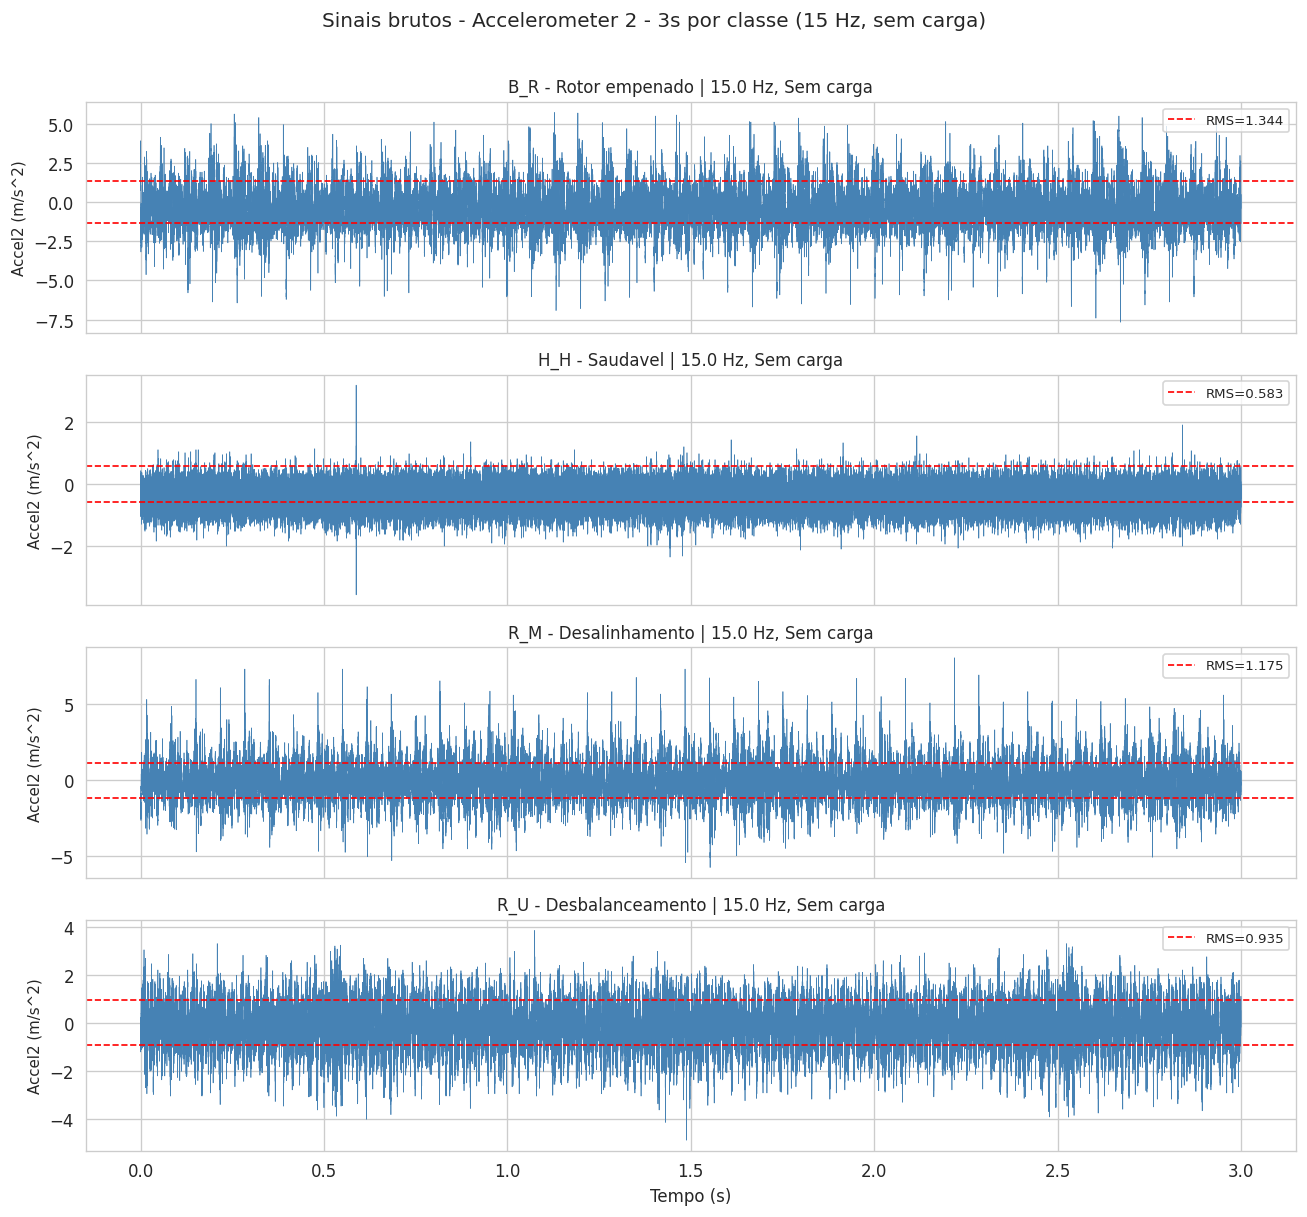

In [ ]:
def load_signal(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, dtype=np.float32)
    df = df.rename(columns={v: k for k, v in COLS.items()})
    return df

# ── Trecho de 3s do Accelerometer 2 (canal limpo) para cada classe, 15Hz sem carga ──
representative = metadata[metadata["speed_hz"] == 15].groupby("label").first().reset_index()
representative = representative.sort_values("label")

fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(11, 10), sharex=True)
t = np.arange(3 * FS) / FS
for ax, (_, row) in zip(axes, representative.iterrows()):
    df = load_signal(row["path"])
    x = df["accel2"].to_numpy()[: 3 * FS]
    rms = np.sqrt(np.mean(x.astype(np.float64) ** 2))
    ax.plot(t, x, lw=0.4, color="steelblue")
    ax.axhline(rms, color="red", lw=1.0, ls="--", label=f"RMS={rms:.3f}")
    ax.axhline(-rms, color="red", lw=1.0, ls="--")
    ax.set_ylabel("Accel2 (m/s^2)", fontsize=9)
    ax.set_title(f"{row['label']} - {row['label_pt']} | {row['speed_hz']} Hz, {row['load_str']}",
                 fontsize=10)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Tempo (s)")
fig.suptitle("Sinais brutos - Accelerometer 2 - 3s por classe (15 Hz, sem carga)", y=1.01)
plt.tight_layout()
plt.savefig("fig01_time_domain.png", bbox_inches="tight", dpi=130)
plt.show()


**Leitura.** O motor saudável (H_H) mostra amplitude visivelmente menor e ausência
de padrão periódico estruturado — consistente com vibração de banda larga sem
componente síncrona dominante. As três classes de falha exibem modulação periódica
clara, coerente com a hipótese de força/momento síncrono ao eixo (RANDALL, 2011,
cap. 4).

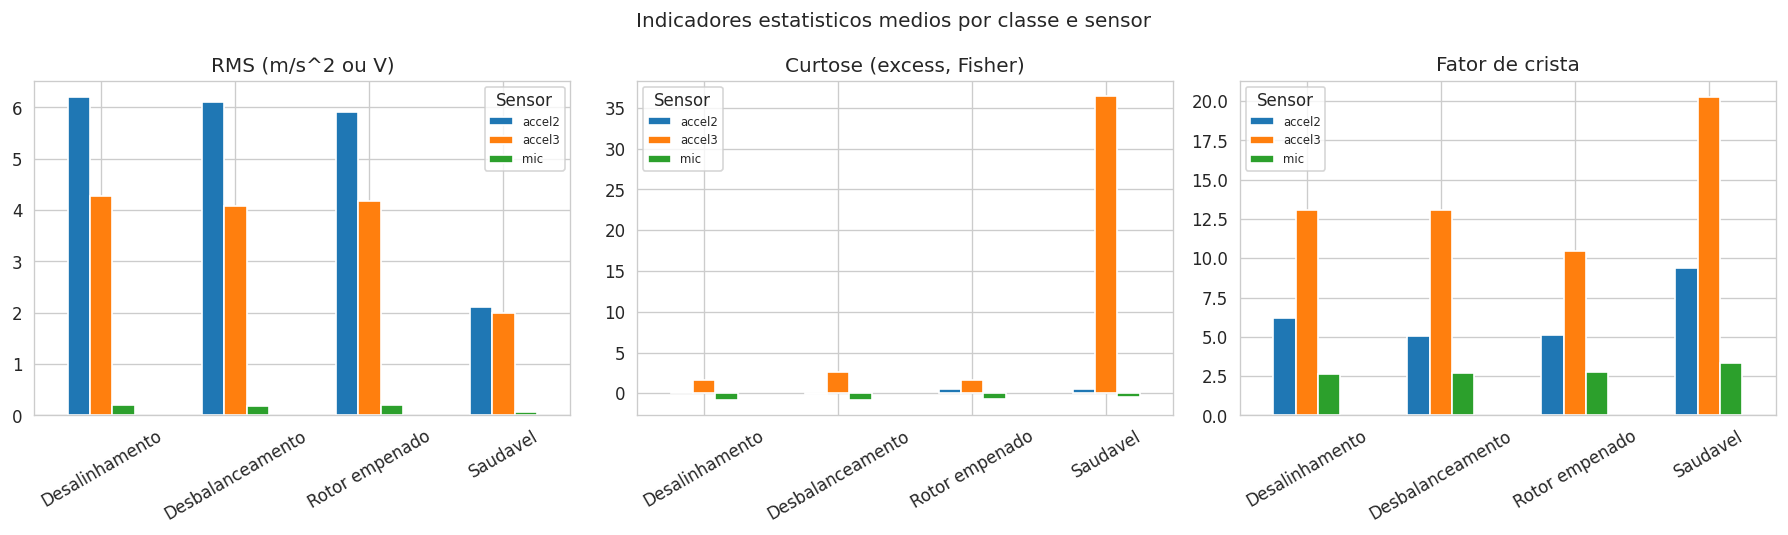

In [ ]:
# ── Indicadores estatisticos por classe e sensor (RMS, curtose, fator de crista) ──
rows = []
for _, meta in metadata.iterrows():
    df = load_signal(meta["path"])
    for key in ALL_SENS:
        x = df[key].to_numpy().astype(np.float64)
        rms = np.sqrt(np.mean(x ** 2))
        rows.append({
            "label": meta["label"], "label_pt": meta["label_pt"], "sensor": key,
            "rms": rms, "kurtosis": kurtosis(x, fisher=True, bias=False),
            "crest": np.max(np.abs(x)) / (rms + 1e-12),
        })
desc_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["rms", "kurtosis", "crest"]
titles = ["RMS (m/s^2 ou V)", "Curtose (excess, Fisher)", "Fator de crista"]
for ax, metric, title in zip(axes, metrics, titles):
    pivot = desc_df[desc_df["sensor"].isin(CLEAN_VIB + ["mic"])].pivot_table(
        index="label_pt", columns="sensor", values=metric, aggfunc="mean")
    pivot.plot(kind="bar", ax=ax, rot=30)
    ax.set_title(title); ax.set_xlabel(""); ax.legend(title="Sensor", fontsize=7)
fig.suptitle("Indicadores estatisticos medios por classe e sensor")
plt.tight_layout()
plt.savefig("fig02_stats_per_class.png", bbox_inches="tight", dpi=130)
plt.show()


### 2.2 Temperatura ao longo do tempo — implicação para o Módulo 2

A variação da temperatura dentro de um mesmo ensaio de 10s é o dado que orienta a
formulação do alvo do softsensor (Seção 9): se o desvio-padrão intra-arquivo for
pequeno frente à variação entre arquivos, o alvo de regressão apropriado é a
temperatura **média do arquivo**, não o valor instantâneo — usar o valor instantâneo
adicionaria apenas ruído de medição ao alvo sem sinal adicional aproveitável.

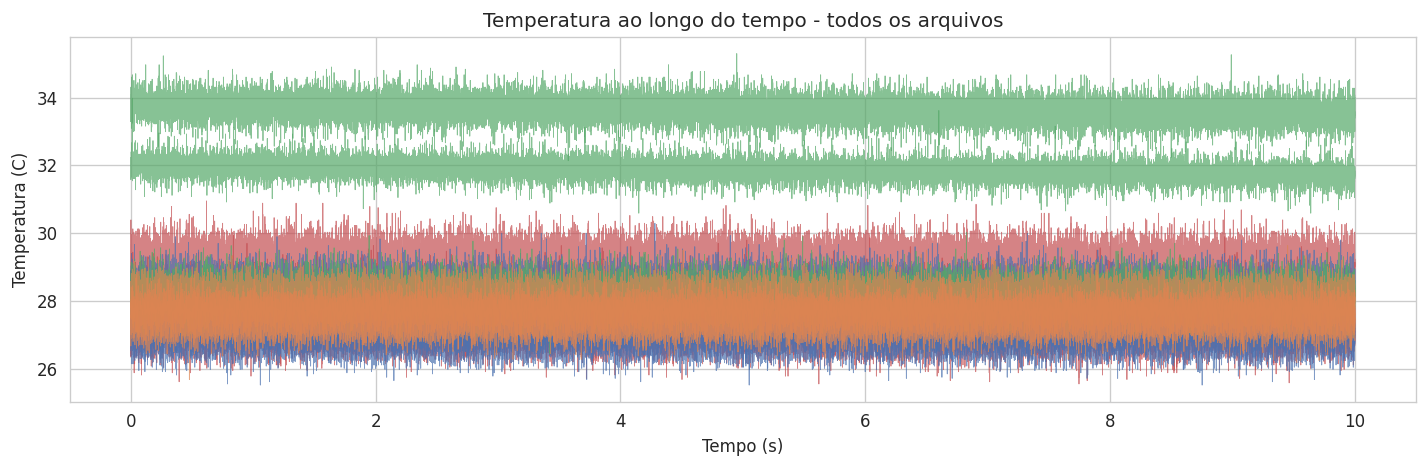

Desvio-padrao da temperatura DENTRO de cada arquivo (10s de ensaio):
file
B_R_1_0    0.1655
B_R_1_1    0.1249
B_R_3_0    0.1450
B_R_3_1    0.1166
H_H_1_0    0.1453
H_H_1_1    0.1280
H_H_3_0    0.1444
H_H_3_1    0.1290
R_M_1_0    0.1475
R_M_1_1    0.1250
R_M_3_0    0.1385
R_M_3_1    0.1156
R_U_1_0    0.1233
R_U_1_1    0.1181
R_U_3_0    0.1079
R_U_3_1    0.1128

Media do desvio-padrao intra-arquivo: 0.1305 C


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = {"H_H": "#4C72B0", "R_U": "#DD8452", "R_M": "#55A868", "B_R": "#C44E52"}
temp_intra_std = []
for _, meta in metadata.iterrows():
    df = pd.read_csv(meta["path"], usecols=[COLS["temp"]], dtype=np.float32)
    temp = df[COLS["temp"]].to_numpy()
    t = np.arange(len(temp)) / FS
    ax.plot(t, temp, lw=0.5, color=colors[meta["label"]], alpha=0.7)
    temp_intra_std.append({"file": meta["file"], "label": meta["label"], "std_intra": temp.std()})
ax.set_xlabel("Tempo (s)"); ax.set_ylabel("Temperatura (C)")
ax.set_title("Temperatura ao longo do tempo - todos os arquivos")
plt.tight_layout()
plt.savefig("fig03_temperature.png", bbox_inches="tight", dpi=130)
plt.show()

temp_intra_df = pd.DataFrame(temp_intra_std)
print("Desvio-padrao da temperatura DENTRO de cada arquivo (10s de ensaio):")
print(temp_intra_df.set_index("file")["std_intra"].round(4).to_string())
print(f"\nMedia do desvio-padrao intra-arquivo: {temp_intra_df['std_intra'].mean():.4f} C")


## 3. EDA — domínio da frequência

### 3.1 Densidade espectral de potência via método de Welch

Uma FFT única de uma janela de 1s (42.000 amostras) produz uma estimativa da
densidade espectral de potência (PSD) com variância estatística alta — cada
"bin" de frequência é uma estimativa de um único grau de liberdade complexo. O
**método de Welch** (WELCH, 1967) reduz essa variância dividindo o sinal em $K$
segmentos (com sobreposição), aplicando uma janela a cada um (aqui, janela de Hann,
que oferece bom compromisso entre vazamento espectral e resolução — HARRIS, 1978) e
promediando os periodogramas resultantes:

$$\hat{S}_{xx}(f) = \frac{1}{K}\sum_{k=0}^{K-1} \frac{1}{U \, F_s}
\left|\sum_{n=0}^{M-1} w[n]\, x_k[n]\, e^{-j2\pi f n/F_s}\right|^2,
\qquad U = \frac{1}{M}\sum_{n=0}^{M-1} w[n]^2$$

onde $M$ é o comprimento de cada segmento, $w[n]$ a janela aplicada, $x_k[n]$ o
$k$-ésimo segmento do sinal, e $U$ o fator de normalização de potência da janela. O
custo é resolução espectral reduzida: $\Delta f = F_s / M$. Usamos $M = 4096$ amostras
(`nperseg=4096`) com sobreposição de 50%, o que dá

$$\Delta f = \frac{42\,000}{4096} \approx 10{,}25 \text{ Hz},$$

resolução suficiente para separar as harmônicas de rotação de interesse (15 Hz, 30 Hz,
45 Hz, 90 Hz, 135 Hz, ...) sem ambiguidade, e reduz a variância da estimativa em
aproximadamente $1/K$ em relação a uma FFT única (WELCH, 1967), ao custo de um viés de
suavização proporcional à largura do lóbulo principal da janela (HARRIS, 1978).
Implementação via `scipy.signal.welch` (VIRTANEN et al., 2020).

### 3.2 Order tracking — por que normalizar pela frequência de rotação

O dicionário de dados do desafio recomenda expressar features espectrais em múltiplos
da frequência de rotação (*order tracking*) em vez de bandas de frequência absolutas,
porque a posição das harmônicas de defeito no espectro é proporcional à velocidade de
rotação do eixo, não fixa (RANDALL, 2011, cap. 5). Formalmente, se $f_{rot}$ é a
frequência de rotação, a energia na $k$-ésima ordem é

$$E_k = \frac{\displaystyle\max_{f \in [k f_{rot} - \delta,\, k f_{rot} + \delta]} \hat{S}_{xx}(f)}
{\displaystyle\sum_{f} \hat{S}_{xx}(f)}$$

com $\delta$ uma tolerância de busca (aqui, ~1,5 bin espectral) que absorve o
escorregamento do motor de indução e pequenos desvios de velocidade do VFD. A
demonstração empírica da Seção 3.3 (mesma falha, duas velocidades) mostra por que
uma banda de frequência absoluta fixa falha ao mudar a velocidade nominal, enquanto a
ordem normalizada continua válida.

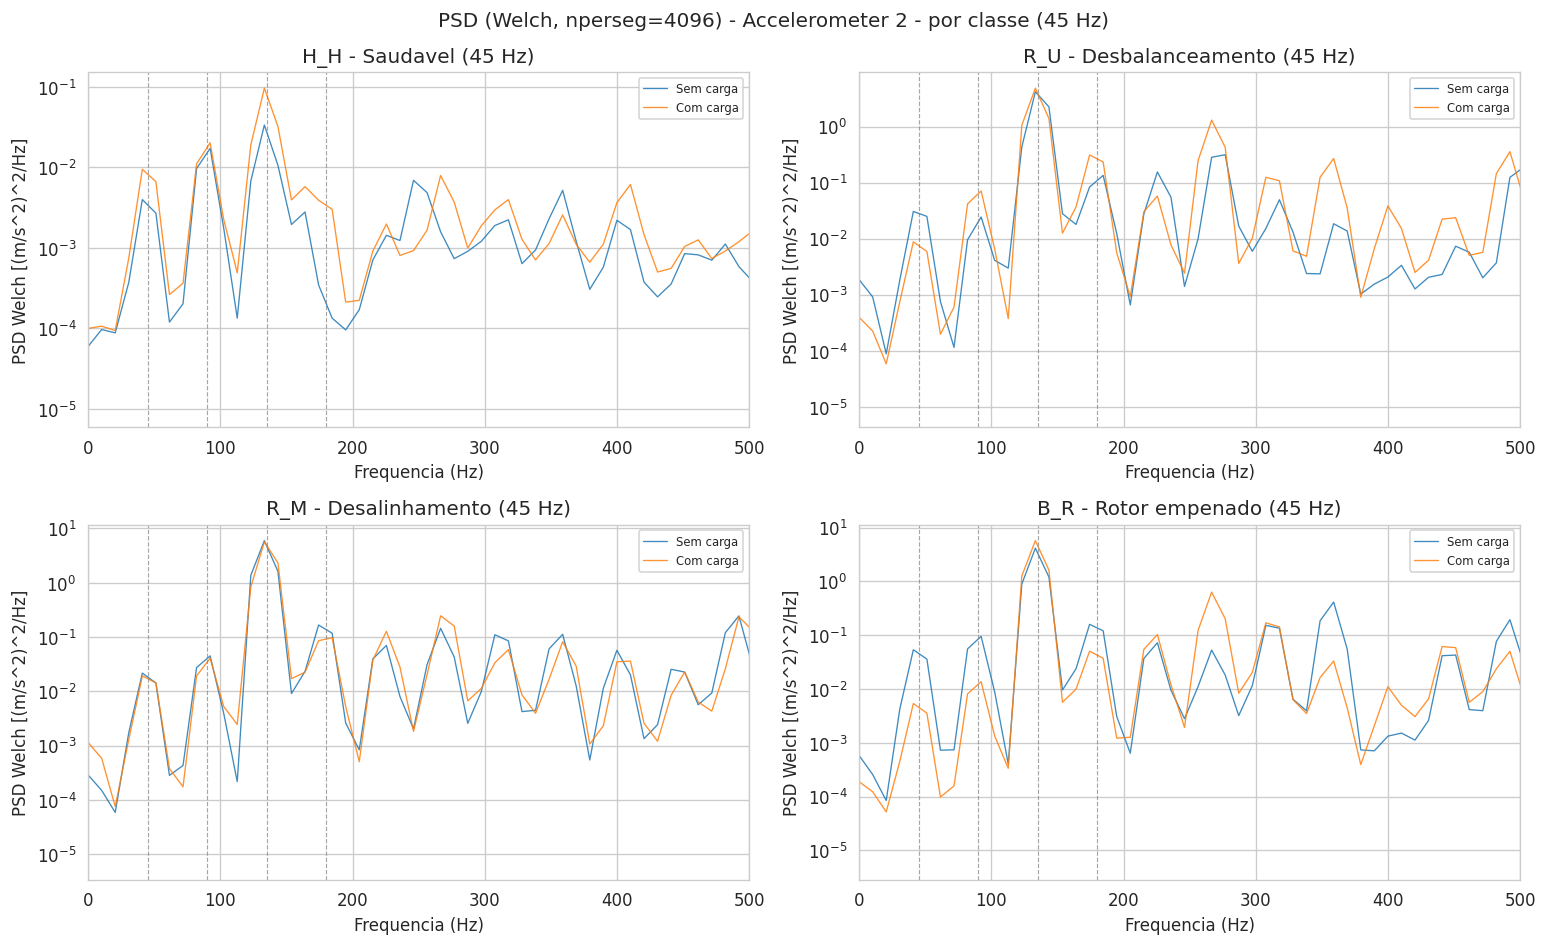

In [ ]:
FS_WELCH_NPERSEG = 4096

def welch_psd(x: np.ndarray, fs: int = FS, nperseg: int = FS_WELCH_NPERSEG):
    freqs, psd = sig.welch(x.astype(np.float64), fs=fs, nperseg=nperseg, window="hann")
    return freqs, psd

# ── PSD (Welch) por classe, Accelerometer 2, 45 Hz ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()
for ax, label in zip(axes, CLASS_NAMES.keys()):
    rows_45 = metadata[(metadata["label"] == label) & (metadata["speed_hz"] == 45)]
    for _, meta in rows_45.iterrows():
        df = load_signal(meta["path"])
        freqs, psd = welch_psd(df["accel2"].to_numpy())
        ax.semilogy(freqs, psd, lw=0.8, alpha=0.85, label=meta["load_str"])
    for order in (1, 2, 3, 4):
        hz = order * 45
        ax.axvline(hz, color="grey", ls="--", lw=0.7, alpha=0.7)
    ax.set_xlim(0, 500)
    ax.set_xlabel("Frequencia (Hz)"); ax.set_ylabel("PSD Welch [(m/s^2)^2/Hz]")
    ax.set_title(f"{label} - {CLASS_NAMES[label]} (45 Hz)")
    ax.legend(fontsize=7)
fig.suptitle("PSD (Welch, nperseg=4096) - Accelerometer 2 - por classe (45 Hz)")
plt.tight_layout()
plt.savefig("fig04_psd_welch_per_class.png", bbox_inches="tight", dpi=130)
plt.show()


### 3.3 Comparação 15 Hz × 45 Hz — mesma falha, ordens diferentes

Esta é a demonstração empírica direta do argumento da Seção 3.2: para a **mesma
falha** (R_U, desbalanceamento), comparamos o espectro a 15 Hz e a 45 Hz. Se uma
feature fosse definida por uma **banda de frequência absoluta fixa** (ex.: "energia
entre 14–16 Hz"), ela detectaria a assinatura em 15 Hz mas perderia completamente a
mesma assinatura física a 45 Hz — porque a harmônica relevante migrou para ~45 Hz. Uma
feature de *order tracking* (energia relativa à ordem $k f_{rot}$), por outro lado,
"acompanha" a harmônica automaticamente.

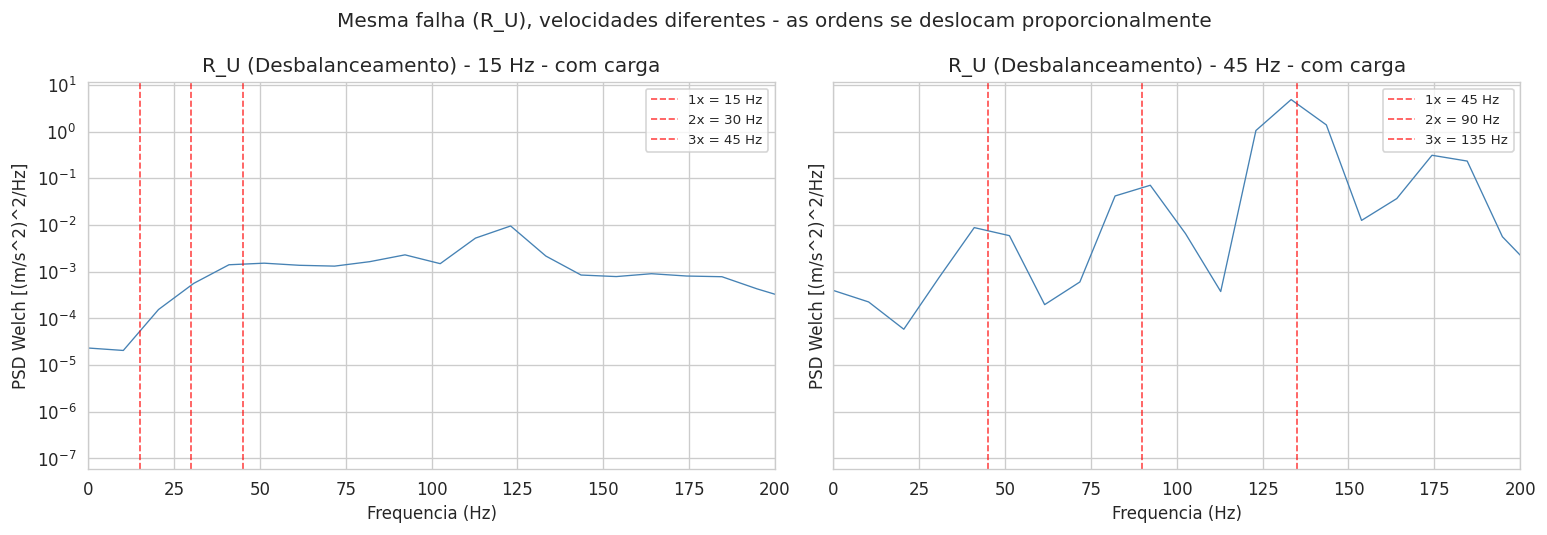

Observacao critica: uma banda de frequencia absoluta (ex. 14-16 Hz) capturaria
a assinatura em 15 Hz mas ficaria muda a 45 Hz. Order tracking normalizado pela
frequencia de rotacao e robusto a essa mudanca (RANDALL, 2011).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, speed in zip(axes, [15.0, 45.0]):
    row = metadata[(metadata["label"] == "R_U") & (metadata["speed_hz"] == speed) &
                    (metadata["load"] == 1)].iloc[0]
    df = load_signal(row["path"])
    freqs, psd = welch_psd(df["accel2"].to_numpy())
    ax.semilogy(freqs, psd, lw=0.8, color="steelblue")
    ax.set_xlim(0, 200)
    ax.set_xlabel("Frequencia (Hz)"); ax.set_ylabel("PSD Welch [(m/s^2)^2/Hz]")
    ax.set_title(f"R_U (Desbalanceamento) - {speed:.0f} Hz - com carga")
    for order in (1, 2, 3):
        hz = order * speed
        ax.axvline(hz, color="red", ls="--", lw=1.0, alpha=0.7, label=f"{order}x = {hz:.0f} Hz")
    ax.legend(fontsize=8)
fig.suptitle("Mesma falha (R_U), velocidades diferentes - as ordens se deslocam proporcionalmente")
plt.tight_layout()
plt.savefig("fig05_speed_comparison.png", bbox_inches="tight", dpi=130)
plt.show()

print("Observacao critica: uma banda de frequencia absoluta (ex. 14-16 Hz) capturaria")
print("a assinatura em 15 Hz mas ficaria muda a 45 Hz. Order tracking normalizado pela")
print("frequencia de rotacao e robusto a essa mudanca (RANDALL, 2011).")


### 3.4 Espectrograma (STFT) — verificação de (não-)estacionariedade

Toda a análise espectral das seções 3.1–3.3 assume implicitamente que o sinal é
**estacionário** dentro da janela de 1s usada para o cálculo da PSD (a própria
mediação de Welch, Seção 3.1, pressupõe que os $K$ segmentos amostram o mesmo processo
subjacente). Essa suposição não deve ser aceita sem verificação. A ferramenta padrão
para isso é o **espectrograma**, obtido pela Transformada de Fourier de Tempo Curto
(STFT — *Short-Time Fourier Transform*), que aplica a mesma ideia de janelamento da
PSD de Welch mas preserva o eixo do tempo em vez de promediá-lo:

$$X(t, f) = \sum_{n} x[n]\, w[n - tH]\, e^{-j2\pi f n/F_s}, \qquad
\text{Espectrograma}(t,f) = |X(t,f)|^{2}$$

onde $w$ é a janela deslizante (aqui, também Hann), $H$ o passo (*hop*) entre janelas
sucessivas, e $t$ indexa o instante central de cada janela (OPPENHEIM; SCHAFER, 2010,
cap. 10). Se a energia em cada banda de frequência de interesse permanecer
aproximadamente constante ao longo dos 10s do ensaio, isso corrobora a suposição de
estacionariedade usada implicitamente na Seção 3.1 e também no desenho de janelamento
da Seção 4.1 (janelas de 1s tratadas como amostras comparáveis do mesmo processo).
Se, ao contrário, houver mudança visível ao longo do tempo, isso seria evidência de
efeitos transitórios (ex.: aquecimento progressivo, afrouxamento gradual) que a PSD
média mascararia.

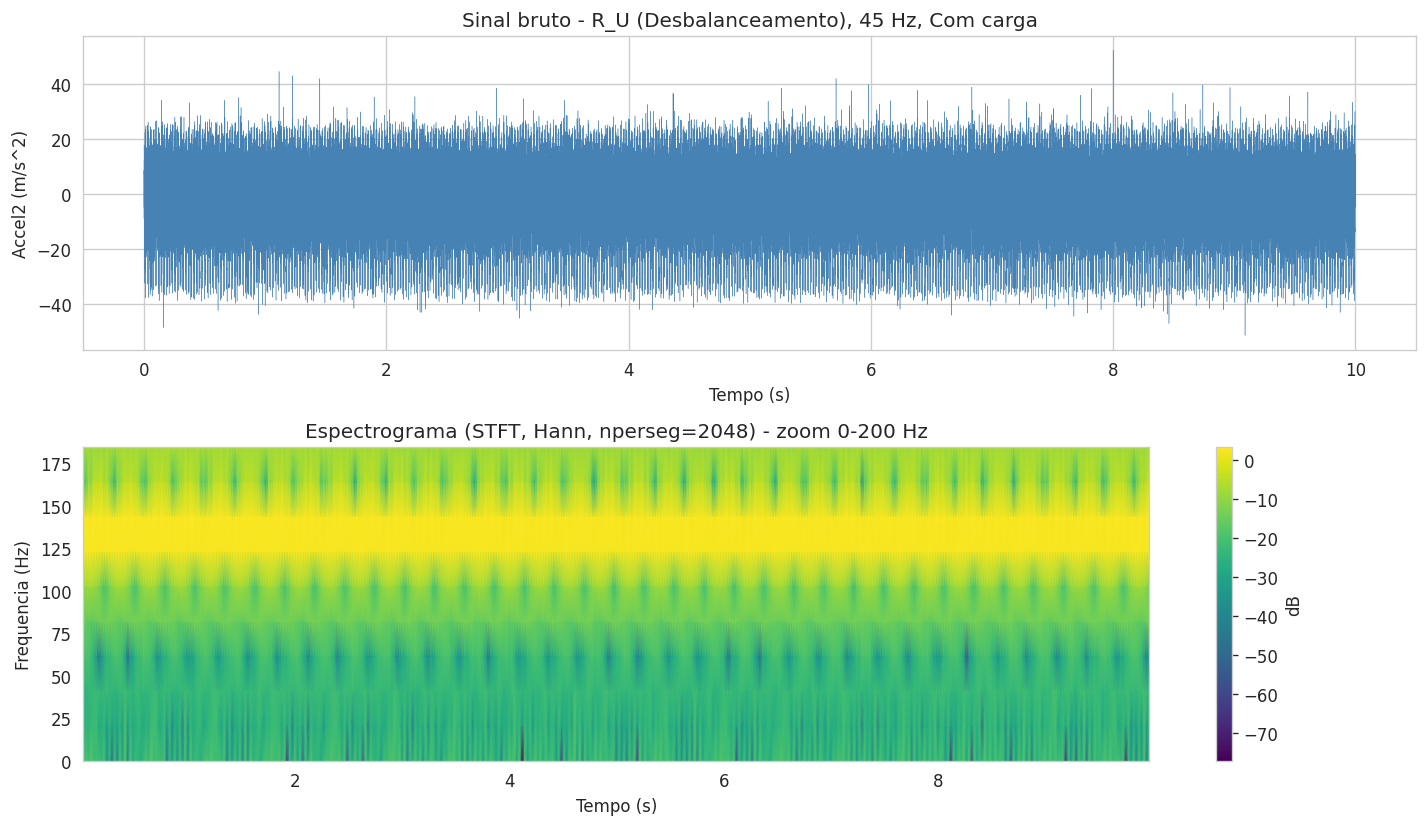

Coeficiente de variacao temporal da energia em banda (0-200Hz): 0.059
(valores baixos, tipicamente < 0.5, sao consistentes com a hipotese de sinal
 aproximadamente estacionario ao longo dos 10s do ensaio)


In [ ]:
# ── Espectrograma (STFT) para uma condicao representativa ────────────────────
row_stft = metadata[(metadata["label"] == "R_U") & (metadata["speed_hz"] == 45) &
                     (metadata["load"] == 1)].iloc[0]
df_stft = load_signal(row_stft["path"])
x_stft = df_stft["accel2"].to_numpy().astype(np.float64)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
t_vec = np.arange(len(x_stft)) / FS
axes[0].plot(t_vec, x_stft, lw=0.25, color="steelblue")
axes[0].set_ylabel("Accel2 (m/s^2)"); axes[0].set_xlabel("Tempo (s)")
axes[0].set_title(f"Sinal bruto - {row_stft['label']} ({row_stft['label_pt']}), "
                   f"{row_stft['speed_hz']:.0f} Hz, {row_stft['load_str']}")

f_spec, t_spec, Sxx = sig.spectrogram(x_stft, fs=FS, nperseg=2048, noverlap=1024, window="hann")
freq_mask = f_spec <= 200
im = axes[1].pcolormesh(t_spec, f_spec[freq_mask], 10 * np.log10(Sxx[freq_mask] + 1e-12),
                         shading="gouraud", cmap="viridis")
axes[1].set_ylabel("Frequencia (Hz)"); axes[1].set_xlabel("Tempo (s)")
axes[1].set_title("Espectrograma (STFT, Hann, nperseg=2048) - zoom 0-200 Hz")
fig.colorbar(im, ax=axes[1], label="dB")
plt.tight_layout()
plt.savefig("fig_stft_spectrogram.png", bbox_inches="tight", dpi=130)
plt.show()

# Quantifica a estacionariedade: desvio-padrao da energia em banda ao longo do tempo,
# normalizado pela media (coeficiente de variacao temporal)
band_energy_over_time = Sxx[freq_mask].sum(axis=0)
cv_temporal = band_energy_over_time.std() / (band_energy_over_time.mean() + 1e-12)
print(f"Coeficiente de variacao temporal da energia em banda (0-200Hz): {cv_temporal:.3f}")
print("(valores baixos, tipicamente < 0.5, sao consistentes com a hipotese de sinal")
print(" aproximadamente estacionario ao longo dos 10s do ensaio)")


## 4. Engenharia de features

### 4.1 Estratégia de janelamento

Cada arquivo (10s @ 42kHz) é dividido em janelas de **1 segundo (42.000 amostras) com
50% de sobreposição** (hop = 21.000 amostras) → 19 janelas por arquivo → 304 janelas
no total (76 por classe). A sobreposição aumenta a densidade de amostras de treino sem
exigir sinal adicional (prática usual em diagnóstico de vibração), ao custo de
correlação entre janelas vizinhas do mesmo arquivo — por isso o agrupamento por
**arquivo/condição** (não por janela) é obrigatório na validação (Seção 5); do
contrário, essa correlação vira vazamento de dados (KAUFMAN et al., 2012).

### 4.2 Features de domínio da frequência (além das já definidas na Seção 3)

**Centroide espectral** (frequência "média" ponderada pela energia — indica onde a
energia do sinal está concentrada):
$$C = \frac{\sum_f f \cdot \hat{S}_{xx}(f)}{\sum_f \hat{S}_{xx}(f)}$$

**Entropia espectral** (normalizada, $0 \le H \le 1$) — mede o quão "espalhada"
(ruído de banda larga, $H \to 1$) ou concentrada (poucos picos dominantes, $H \to 0$)
é a distribuição de energia no espectro, com $p(f) = \hat{S}_{xx}(f) / \sum_f \hat{S}_{xx}(f)$
e $N_f$ o número de bins de frequência (conceito derivado da entropia de Shannon —
SHANNON, 1949):
$$H = -\frac{1}{\log_2 N_f}\sum_f p(f)\, \log_2 p(f)$$

**Rolloff espectral (85%)** — frequência $f_{85}$ abaixo da qual está concentrada 85%
da energia total do espectro:
$$f_{85} = \min\Big\{ f : \sum_{f' \le f} \hat{S}_{xx}(f') \ge 0{,}85 \sum_{f'} \hat{S}_{xx}(f') \Big\}$$

### 4.3 Features de correlação cruzada entre sensores

O dicionário de dados observa que o Accelerometer 1 (drive-end) é o canal
eletricamente mais ruidoso (contaminado por chaveamento do VFD), enquanto
Accelerometer 2 e 3 (posicionados ao longo do eixo) são mais limpos. Como B_R (rotor
empenado) é fisicamente descrito como capaz de gerar **vibração axial e radial
acopladas**, a hipótese natural é que o grau de acoplamento entre pares de sensores —
não capturado por estatísticas de canal único — carregue informação diagnóstica
adicional. Implementamos 3 features por janela:

**(1) Correlação de Pearson entre Accelerometer 2 e Accelerometer 3** (acoplamento
entre duas posições axiais distintas do eixo):
$$\rho_{23} = \frac{\sum_{n}(x_2[n]-\bar{x}_2)(x_3[n]-\bar{x}_3)}
{\sqrt{\sum_n (x_2[n]-\bar{x}_2)^2}\;\sqrt{\sum_n (x_3[n]-\bar{x}_3)^2}}$$

**(2) Correlação de Pearson entre Accelerometer 2 e o Microfone** (acoplamento
estrutura-acústico).

**(3) Coerência espectral (magnitude ao quadrado) entre Accelerometer 2 e
Accelerometer 3, avaliada na 1ª ordem de rotação** — mede, especificamente na
frequência onde a assinatura de falha síncrona é mais forte, o quanto a energia dos
dois canais está linearmente relacionada em fase/frequência (não apenas correlacionada
no domínio do tempo). Definida, para dois sinais $x, y$, via densidade espectral
cruzada de Welch $\hat{S}_{xy}(f)$ (mesmo estimador da Seção 3.1, mas aplicado ao
produto cruzado):
$$C_{xy}(f) = \frac{|\hat{S}_{xy}(f)|^{2}}{\hat{S}_{xx}(f)\,\hat{S}_{yy}(f)}, \qquad 0 \le C_{xy}(f) \le 1$$
avaliada em $f \approx f_{rot}$ (implementação via `scipy.signal.coherence` —
VIRTANEN et al., 2020).

Esta última é a mais informativa das três: enquanto a correlação de Pearson (item 1)
mistura todas as frequências do sinal, a coerência isolada na 1ª ordem foca
especificamente na componente síncrona ao eixo, que é onde a literatura de
diagnóstico associa a assinatura mais forte de desbalanceamento/desalinhamento
(RANDALL; ANTONI, 2011).

In [ ]:
FREQ_BANDS = [(0, 500), (500, 2000), (2000, 5000), (5000, 10000), (10000, 21000)]
EPS = 1e-12


def time_domain_features(x: np.ndarray, prefix: str) -> dict:
    x = x.astype(np.float64)
    rms = np.sqrt(np.mean(x ** 2))
    peak = np.max(np.abs(x))
    mean_abs = np.mean(np.abs(x))
    return {
        f"{prefix}_rms": rms, f"{prefix}_std": np.std(x),
        f"{prefix}_mean_abs": mean_abs, f"{prefix}_peak": peak,
        f"{prefix}_p2p": np.ptp(x), f"{prefix}_crest_factor": peak / (rms + EPS),
        f"{prefix}_shape_factor": rms / (mean_abs + EPS),
        f"{prefix}_impulse_factor": peak / (mean_abs + EPS),
        f"{prefix}_kurtosis": kurtosis(x, fisher=True, bias=False),
        f"{prefix}_skewness": skew(x, bias=False),
    }


def freq_domain_features(x: np.ndarray, fs: int, prefix: str, f_rot: float) -> dict:
    x = x.astype(np.float64)
    freqs, psd = welch_psd(x, fs=fs)
    total_energy = np.sum(psd) + EPS

    centroid = np.sum(freqs * psd) / total_energy
    p = psd / total_energy
    spectral_entropy = -np.sum(p * np.log2(p + EPS)) / np.log2(len(p))
    cumulative = np.cumsum(psd)
    rolloff_idx = min(np.searchsorted(cumulative, 0.85 * total_energy), len(freqs) - 1)
    rolloff85 = freqs[rolloff_idx]

    feats = {
        f"{prefix}_spec_centroid": centroid,
        f"{prefix}_spec_entropy": spectral_entropy,
        f"{prefix}_spec_rolloff85": rolloff85,
    }
    for lo, hi in FREQ_BANDS:
        mask = (freqs >= lo) & (freqs < hi)
        feats[f"{prefix}_band_{lo}_{hi}"] = np.sum(psd[mask]) / total_energy

    freq_res = fs / FS_WELCH_NPERSEG
    tol_bins = max(1, int(round(1.5 * freq_res / freq_res)))  # ~1-2 bins de tolerancia
    for order in (1, 2, 3):
        target = order * f_rot
        center_bin = int(round(target / freq_res))
        lo_bin, hi_bin = max(0, center_bin - tol_bins), min(len(psd), center_bin + tol_bins + 1)
        harmonic_energy = np.max(psd[lo_bin:hi_bin]) if hi_bin > lo_bin else 0.0
        feats[f"{prefix}_order_{order}x"] = harmonic_energy / total_energy
    return feats


def cross_sensor_features(sig_dict: dict, fs: int, f_rot: float) -> dict:
    x2, x3, xm = sig_dict["accel2"], sig_dict["accel3"], sig_dict["mic"]

    def pearson(a, b):
        c = np.corrcoef(a.astype(np.float64), b.astype(np.float64))[0, 1]
        return 0.0 if np.isnan(c) else c

    feats = {
        "corr_accel2_accel3": pearson(x2, x3),
        "corr_accel2_mic": pearson(x2, xm),
    }
    freqs, coh = sig.coherence(x2.astype(np.float64), x3.astype(np.float64),
                                fs=fs, nperseg=FS_WELCH_NPERSEG)
    idx = np.argmin(np.abs(freqs - f_rot))
    feats["coherence_accel2_accel3_1x"] = float(coh[idx])
    return feats


def extract_window_features(window_df: pd.DataFrame, fs: int, f_rot: float) -> dict:
    feats = {}
    sig_dict = {}
    for ch in ALL_SENS:
        x = window_df[ch].to_numpy()
        sig_dict[ch] = x
        feats.update(time_domain_features(x, ch))
        feats.update(freq_domain_features(x, fs, ch, f_rot))
    feats.update(cross_sensor_features(sig_dict, fs, f_rot))
    return feats


# teste rapido em uma janela
_df0 = load_signal(metadata.iloc[0]["path"])
_w0 = _df0.iloc[:WIN_SIZE]
_f0 = extract_window_features(_w0, FS, float(metadata.iloc[0]["speed_hz"]))
print(f"{len(_f0)} features por janela (esperado: 4 canais x 21 + 3 cross-sensor = 87)")


87 features por janela (esperado: 4 canais x 21 + 3 cross-sensor = 87)


### 4.4 Extração de features em todos os arquivos

Executa o janelamento (1s, 50% overlap) e a extração de features em todos os 16
arquivos, gerando a tabela final usada em toda a análise subsequente.

In [ ]:
def iter_windows(n_total: int, win_size: int, hop: int):
    start = 0
    while start + win_size <= n_total:
        yield start
        start += hop


WIN_SECONDS = 1.0
OVERLAP = 0.5
WIN_N = int(WIN_SECONDS * FS)
HOP_N = int(WIN_N * (1 - OVERLAP))

rows = []
for _, meta in metadata.iterrows():
    df = load_signal(meta["path"])
    f_rot = float(meta["speed_hz"])
    for w_start in iter_windows(len(df), WIN_N, HOP_N):
        window = df.iloc[w_start: w_start + WIN_N]
        feats = extract_window_features(window, FS, f_rot)
        feats.update({
            "file_id": meta["file"], "classe": meta["label"],
            "speed_hz": meta["speed_hz"], "load": meta["load_str"],
            "window_start_s": w_start / FS,
            "temperature_mean_window": float(window["temp"].mean()),
        })
        rows.append(feats)
    print(f"[{meta['file']}] {sum(1 for _ in iter_windows(len(df), WIN_N, HOP_N))} janelas ok")

feat_df = pd.DataFrame(rows)
META_COLS = ["file_id", "classe", "speed_hz", "load", "window_start_s",
             "temperature_mean_window"]
FEATURE_COLS = [c for c in feat_df.columns if c not in META_COLS]
print(f"\nTabela de features: {feat_df.shape[0]} janelas x {len(FEATURE_COLS)} features")
feat_df.to_parquet("features.parquet", index=False)
feat_df.head()


[B_R_1_0] 19 janelas ok
[B_R_1_1] 19 janelas ok
[B_R_3_0] 19 janelas ok
[B_R_3_1] 19 janelas ok
[H_H_1_0] 19 janelas ok
[H_H_1_1] 19 janelas ok
[H_H_3_0] 19 janelas ok
[H_H_3_1] 19 janelas ok
[R_M_1_0] 19 janelas ok
[R_M_1_1] 19 janelas ok
[R_M_3_0] 19 janelas ok
[R_M_3_1] 19 janelas ok
[R_U_1_0] 19 janelas ok
[R_U_1_1] 19 janelas ok
[R_U_3_0] 19 janelas ok
[R_U_3_1] 19 janelas ok

Tabela de features: 304 janelas x 87 features


,accel1_rms,accel1_std,accel1_mean_abs,accel1_peak,accel1_p2p,accel1_crest_factor,accel1_shape_factor,accel1_impulse_factor,accel1_kurtosis,accel1_skewness,...,mic_order_3x,corr_accel2_accel3,corr_accel2_mic,coherence_accel2_accel3_1x,file_id,classe,speed_hz,load,window_start_s,temperature_mean_window
0,4.608020,3.013571,3.768304,16.807043,27.178247,3.647346,1.222837,4.460108,0.963389,0.441605,...,0.395537,-0.388736,-0.051313,0.332216,B_R_1_0,B_R,15.0,Sem carga,0.0,29.179003
1,4.754377,3.043046,3.918716,17.935440,29.370561,3.772406,1.213249,4.576867,1.166846,0.403855,...,0.390122,-0.411470,-0.049035,0.213704,B_R_1_0,B_R,15.0,Sem carga,0.5,29.174580
2,4.922160,3.136635,4.095698,17.935440,29.370561,3.643815,1.201788,4.379092,1.227101,0.251501,...,0.388545,-0.461177,-0.046375,0.091916,B_R_1_0,B_R,15.0,Sem carga,1.0,29.169191
3,5.001523,3.058023,4.177719,17.548561,27.468406,3.508643,1.197190,4.200513,1.079464,0.415029,...,0.403312,-0.400431,-0.052700,0.198306,B_R_1_0,B_R,15.0,Sem carga,1.5,29.164919
4,5.132070,3.088233,4.305548,21.997669,34.496707,4.286315,1.191967,5.109146,1.377388,0.411909,...,0.393428,-0.413664,-0.048006,0.199663,B_R_1_0,B_R,15.0,Sem carga,2.0,29.161057


### 4.5 Correlação univariada com o rótulo — verificação exploratória

Antes de treinar qualquer modelo multivariado, é útil inspecionar, feature a feature,
o quão associada cada uma está isoladamente com a classe de falha — um **método de
filtro** (*filter method*) de seleção/triagem de variáveis, na taxonomia de GUYON;
ELISSEEFF (2003). Para cada feature $x_j$, calculamos a correlação de Pearson com o
rótulo numérico $y$ (classes codificadas como inteiros via `LabelEncoder`):

$$r_j = \frac{\sum_i (x_{ij} - \bar{x}_j)(y_i - \bar{y})}
{\sqrt{\sum_i (x_{ij}-\bar{x}_j)^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}}$$

**Ressalva metodológica importante** (para não superinterpretar este gráfico): a
codificação numérica de um rótulo categórico nominal é arbitrária (não há ordem
natural entre H_H, R_U, R_M, B_R), então $|r_j|$ aqui funciona apenas como um
indicador aproximado de separabilidade da feature entre classes — não uma medida
formal de dependência estatística, e **não captura interações entre features**, que é
exatamente o que Random Forest e XGBoost exploram (GUYON; ELISSEEFF, 2003, seção 2,
discutem essa limitação de métodos de filtro univariados frente a métodos
*embedded*/wrapper como os modelos baseados em árvore usados neste desafio). Este
gráfico é, portanto, complementar — não substitui — a importância de features nativa
dos modelos (Seções 8.4 e 8.5), que é multivariada por construção.

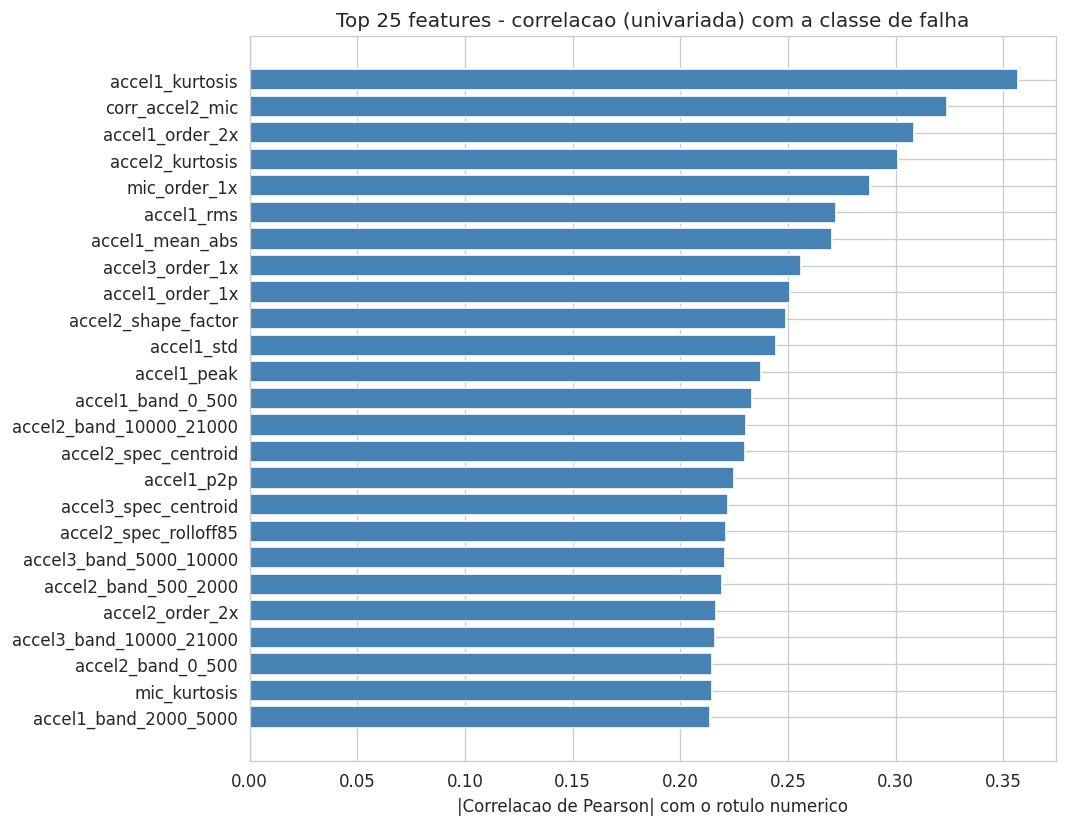

Top 10 features por correlacao absoluta com o rotulo:
            feature  abs_corr
    accel1_kurtosis  0.356674
    corr_accel2_mic  0.323883
    accel1_order_2x  0.308605
    accel2_kurtosis  0.301017
       mic_order_1x  0.287900
         accel1_rms  0.272165
    accel1_mean_abs  0.270536
    accel3_order_1x  0.256238
    accel1_order_1x  0.250797
accel2_shape_factor  0.249179


In [ ]:
_le_tmp = LabelEncoder()
y_enc_full = _le_tmp.fit_transform(feat_df["classe"])
corr_rows = []
for col in FEATURE_COLS:
    r = np.corrcoef(feat_df[col].to_numpy(dtype=float), y_enc_full)[0, 1]
    corr_rows.append({"feature": col, "abs_corr": abs(r) if not np.isnan(r) else 0.0})
corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(corr_df["feature"][::-1], corr_df["abs_corr"][::-1], color="steelblue")
ax.set_xlabel("|Correlacao de Pearson| com o rotulo numerico")
ax.set_title("Top 25 features - correlacao (univariada) com a classe de falha")
plt.tight_layout()
plt.savefig("fig_top25_correlacao_label.png", bbox_inches="tight", dpi=130)
plt.show()

print("Top 10 features por correlacao absoluta com o rotulo:")
print(corr_df.head(10).to_string(index=False))


## 5. Estratégia de validação — leave-one-condition-out

### 5.1 Por que um split ingênuo vaza dados

Janelas vizinhas do mesmo arquivo compartilham a mesma instância física de defeito e a
mesma condição de operação. Um split que particiona **janelas** aleatoriamente entre
treino e teste — ignorando de qual arquivo cada janela veio — permite que o modelo
"memorize" características específicas daquele ensaio (não da classe de falha em
geral), inflando artificialmente a métrica de teste. Este é o padrão clássico de
vazamento de dados por agrupamento não respeitado (*leakage via non-independent
splits*), documentado formalmente por KAUFMAN et al. (2012) e por VARMA; SIMON (2006)
no contexto mais amplo de viés otimista em seleção de modelo via validação cruzada. A
correção padrão é garantir que o **grupo** que gera dependência estatística (aqui, o
arquivo de origem) nunca apareça simultaneamente em treino e teste — friso implementado
via `GroupKFold`/`LeaveOneGroupOut` do scikit-learn (PEDREGOSA et al., 2011), ou, como
abaixo, via um agrupamento customizado.

### 5.2 Por que leave-one-condition-out (e não leave-one-file-out simples)

O dataset tem exatamente **1 arquivo por combinação (classe, velocidade, carga)**.
Isso implica que qualquer split por arquivo deixa, estruturalmente, pelo menos uma
combinação totalmente fora do treino. Duas variantes de agrupamento são possíveis:

- **Leave-one-file-out** (16 folds; a cada fold, 1 arquivo — 1 classe, 1 condição —
  sai para teste, os outros 15 permanecem em treino): o modelo ainda vê a mesma
  condição operacional do teste para as **outras 3 classes** durante o treino.
- **Leave-one-condition-out** (4 folds; a cada fold, uma combinação (velocidade,
  carga) inteira — as 4 classes daquela condição — sai para teste): nenhuma classe
  jamais vê aquela condição operacional durante o treino.

Adotamos a segunda variante porque ela mede diretamente a pergunta relevante em
manutenção preditiva: *o modelo generaliza para uma condição operacional nunca vista,
para qualquer classe?* — mais próxima do cenário real de implantação, onde a máquina
opera em combinações de carga/velocidade que não estarão todas representadas no
histórico de treino (LEI et al., 2020, discutem esse tipo de *domain shift* entre
condições operacionais como um dos principais desafios de generalização em
diagnóstico de falhas orientado a dados).

**Nota de rigor sobre agregação de métricas em CV agrupada.** Ao reportar uma métrica
de classificação multiclasse calculada por *fold* de validação cruzada, é essencial
que cada fold contenha exemplos de todas as classes de interesse — caso contrário,
uma média "macro" por fold é calculada sobre classes com suporte zero, degenerando a
métrica (precision/recall indefinidos tratados como zero, penalizando indevidamente o
fold). A forma correta e a que adotamos aqui é: (1) garantir que cada fold de teste
contenha todas as classes (verdade, por construção, no nosso esquema — cada fold retira
uma condição inteira, com as 4 classes presentes), e (2) sempre que uma média única e
estável for necessária, agregar as predições de **todos os folds antes de calcular a
métrica final** (SOKOLOVA; LAPALME, 2009, discutem esse tipo de cuidado na escolha e
composição de métricas multiclasse).

In [ ]:
CONDITIONS = [(15.0, "Sem carga"), (15.0, "Com carga"),
              (45.0, "Sem carga"), (45.0, "Com carga")]
OFFICIAL_TEST_CONDITION = (45.0, "Com carga")

le = LabelEncoder()
y_all = le.fit_transform(feat_df["classe"])
X_all = feat_df[FEATURE_COLS]

print("Classes:", list(le.classes_))
print("Condicoes (velocidade, carga):", CONDITIONS)


Classes: ['B_R', 'H_H', 'R_M', 'R_U']
Condicoes (velocidade, carga): [(15.0, 'Sem carga'), (15.0, 'Com carga'), (45.0, 'Sem carga'), (45.0, 'Com carga')]


## 6. Diagnóstico quantificado do impacto do vazamento de dados

Para tornar concreto o argumento da Seção 5.1, comparamos diretamente:

- **(a)** o F1-macro do split leakage-safe (leave-one-condition-out), calculado
  agregando as predições de todos os folds antes de computar a métrica (Seção 5.2);
- **(b)** o F1-macro de um split ingênuo por **janela** (`StratifiedKFold`, 5 folds),
  que ignora o arquivo de origem.

O F1-macro (média não ponderada do F1 por classe) é a métrica escolhida em vez da
acurácia simples porque pondera todas as classes igualmente, independente de
frequência — apropriado aqui porque o dataset é balanceado por construção, mas o
objetivo é medir generalização igualmente bem para todas as classes, não apenas a
classe majoritária de um fold específico (SOKOLOVA; LAPALME, 2009).

In [ ]:
MODEL_FACTORIES = {
    "RandomForest": lambda: RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2, class_weight="balanced",
        random_state=RNG_SEED, n_jobs=-1),
    "XGBoost": lambda: XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9,
        colsample_bytree=0.8, reg_lambda=1.0, objective="multi:softprob",
        eval_metric="mlogloss", random_state=RNG_SEED, n_jobs=-1),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
leaky_results = {}
for name, factory in MODEL_FACTORIES.items():
    scores = []
    for tr_idx, te_idx in skf.split(X_all, y_all):
        model = factory()
        model.fit(X_all.iloc[tr_idx], y_all[tr_idx])
        pred = model.predict(X_all.iloc[te_idx])
        scores.append(f1_score(y_all[te_idx], pred, average="macro"))
    leaky_results[name] = float(np.mean(scores))
    print(f"{name}: F1-macro (split de JANELAS, COM vazamento) = {leaky_results[name]:.3f}")


RandomForest: F1-macro (split de JANELAS, COM vazamento) = 1.000
XGBoost: F1-macro (split de JANELAS, COM vazamento) = 1.000


## 7. Classificação — Random Forest × XGBoost (leave-one-condition-out)

### 7.1 Justificativa dos modelos

**Random Forest** (BREIMAN, 2001) constrói um ensemble de árvores de decisão
treinadas em amostras bootstrap dos dados, com seleção aleatória de features a cada
split — o *bagging* reduz variância sem aumentar viés significativamente. **XGBoost**
(CHEN; GUESTRIN, 2016) constrói árvores sequencialmente via *gradient boosting*,
otimizando uma função de perda regularizada; captura interações não-lineares entre
features de forma diferente do bagging (viés menor, variância potencialmente maior).
Comparar os dois é informativo justamente porque seus mecanismos de regularização são
distintos. Ambos: (i) não exigem normalização de features de escalas diferentes, (ii)
expõem importância de features nativamente (`feature_importances_`), útil para
auditar se o modelo aprende assinaturas mecânicas plausíveis (Seção 8.3), e (iii) são
adequados a tabelas de features de tamanho pequeno/moderado como a deste desafio (304
janelas), onde abordagens *end-to-end* de aprendizado profundo tenderiam a
sobreajustar por falta de dados (LEI et al., 2020, seção 4, discutem esse trade-off
entre engenharia de features clássica e aprendizado profundo em diagnóstico de
falhas).

In [ ]:
def run_leave_one_condition_out(X, y, groups_speed, groups_load, model_name, factory):
    all_true, all_pred = [], []
    fold_reports = []
    for speed_hz, load_str in CONDITIONS:
        test_mask = (groups_speed == speed_hz) & (groups_load == load_str)
        train_mask = ~test_mask

        model = factory()
        model.fit(X[train_mask], y[train_mask])
        pred = model.predict(X[test_mask])
        true = y[test_mask]

        all_true.append(true); all_pred.append(pred)
        fold_f1 = f1_score(true, pred, average="macro")  # valido: fold tem as 4 classes
        fold_reports.append({"condition": f"{speed_hz:.0f}Hz_{load_str}",
                              "f1_macro": float(fold_f1), "n_test": int(test_mask.sum())})

    all_true = np.concatenate(all_true); all_pred = np.concatenate(all_pred)
    overall_f1 = f1_score(all_true, all_pred, average="macro")
    precision, recall, f1c, support = precision_recall_fscore_support(
        all_true, all_pred, labels=range(len(le.classes_)))
    cm = confusion_matrix(all_true, all_pred, labels=range(len(le.classes_)))

    return {
        "model": model_name, "fold_reports": fold_reports,
        "overall_f1_macro": float(overall_f1),
        "per_class": {cls: {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}
                      for cls, p, r, f, s in zip(le.classes_, precision, recall, f1c, support)},
        "confusion_matrix": cm.tolist(), "labels": list(le.classes_),
    }


groups_speed = feat_df["speed_hz"].to_numpy()
groups_load = feat_df["load"].to_numpy()
X_np = X_all  # DataFrame indexavel por mascara booleana

cv_results = {}
for name, factory in MODEL_FACTORIES.items():
    res = run_leave_one_condition_out(X_np, y_all, groups_speed, groups_load, name, factory)
    cv_results[name] = res
    print(f"\n=== {name}: leave-one-condition-out (4 folds) ===")
    for fr in res["fold_reports"]:
        print(f"  teste={fr['condition']:16s}  F1-macro={fr['f1_macro']:.3f}  (n={fr['n_test']})")
    print(f"  >> F1-macro agregado (pooled): {res['overall_f1_macro']:.3f}")

print("\n--- Comparativo: impacto do esquema de validacao ---")
for name in MODEL_FACTORIES:
    print(f"{name:15s}  leaky(janelas)={leaky_results[name]:.3f}  "
          f"safe(condicao)={cv_results[name]['overall_f1_macro']:.3f}")



=== RandomForest: leave-one-condition-out (4 folds) ===
  teste=15Hz_Sem carga    F1-macro=0.375  (n=76)
  teste=15Hz_Com carga    F1-macro=0.398  (n=76)
  teste=45Hz_Sem carga    F1-macro=0.612  (n=76)
  teste=45Hz_Com carga    F1-macro=0.660  (n=76)
  >> F1-macro agregado (pooled): 0.588

=== XGBoost: leave-one-condition-out (4 folds) ===
  teste=15Hz_Sem carga    F1-macro=0.727  (n=76)
  teste=15Hz_Com carga    F1-macro=0.167  (n=76)
  teste=45Hz_Sem carga    F1-macro=0.859  (n=76)
  teste=45Hz_Com carga    F1-macro=0.644  (n=76)
  >> F1-macro agregado (pooled): 0.645

--- Comparativo: impacto do esquema de validacao ---
RandomForest     leaky(janelas)=1.000  safe(condicao)=0.588
XGBoost          leaky(janelas)=1.000  safe(condicao)=0.645


## 8. Avaliação detalhada

### 8.1 Impacto do vazamento — visualização

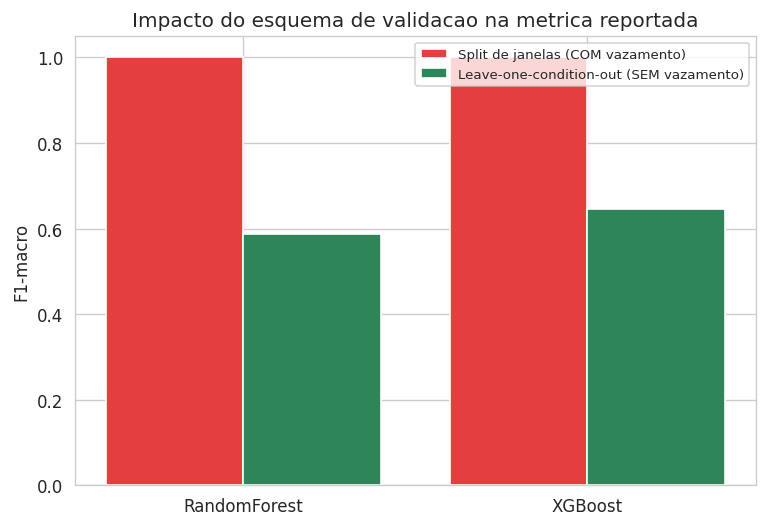

RandomForest: metrica com vazamento e 1.7x maior que a metrica correta.
XGBoost: metrica com vazamento e 1.6x maior que a metrica correta.


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
names = list(MODEL_FACTORIES.keys())
x = np.arange(len(names))
leaky_vals = [leaky_results[n] for n in names]
safe_vals = [cv_results[n]["overall_f1_macro"] for n in names]
ax.bar(x - 0.2, leaky_vals, 0.4, label="Split de janelas (COM vazamento)", color="#e53e3e")
ax.bar(x + 0.2, safe_vals, 0.4, label="Leave-one-condition-out (SEM vazamento)", color="#2f855a")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("F1-macro"); ax.set_ylim(0, 1.05)
ax.set_title("Impacto do esquema de validacao na metrica reportada")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig06_impacto_vazamento.png", bbox_inches="tight", dpi=130)
plt.show()

for n in names:
    ratio = leaky_vals[names.index(n)] / max(safe_vals[names.index(n)], 1e-9)
    print(f"{n}: metrica com vazamento e {ratio:.1f}x maior que a metrica correta.")


### 8.2 Holdout oficial (teste = 45Hz + com carga) e matrizes de confusão

A condição 45Hz+com carga é usada como referência fixa para o relatório de
classificação detalhado e a matriz de confusão, por ser a condição operacional
mecanicamente mais exigente (maior torque, maior velocidade).

In [ ]:
def official_holdout(X, y, groups_speed, groups_load, model_name, factory):
    speed_hz, load_str = OFFICIAL_TEST_CONDITION
    test_mask = (groups_speed == speed_hz) & (groups_load == load_str)
    train_mask = ~test_mask

    model = factory()
    model.fit(X[train_mask], y[train_mask])
    pred = model.predict(X[test_mask])
    true = y[test_mask]

    report = classification_report(true, pred, target_names=le.classes_,
                                    output_dict=True, zero_division=0)
    cm = confusion_matrix(true, pred, labels=range(len(le.classes_)))
    importances = None
    if hasattr(model, "feature_importances_"):
        importances = dict(sorted(zip(X.columns, model.feature_importances_.tolist()),
                                   key=lambda kv: kv[1], reverse=True)[:15])
    return {"model": model_name, "report": report, "confusion_matrix": cm.tolist(),
            "labels": list(le.classes_), "top_features": importances}, model


holdout_results = {}
fitted_models = {}
for name, factory in MODEL_FACTORIES.items():
    res, fitted = official_holdout(X_np, y_all, groups_speed, groups_load, name, factory)
    holdout_results[name] = res
    fitted_models[name] = fitted
    macro = res["report"]["macro avg"]
    print(f"{name}: precision={macro['precision']:.3f}  recall={macro['recall']:.3f}  "
          f"f1={macro['f1-score']:.3f}")


RandomForest: precision=0.608  recall=0.750  f1=0.660
XGBoost: precision=0.608  recall=0.724  f1=0.644


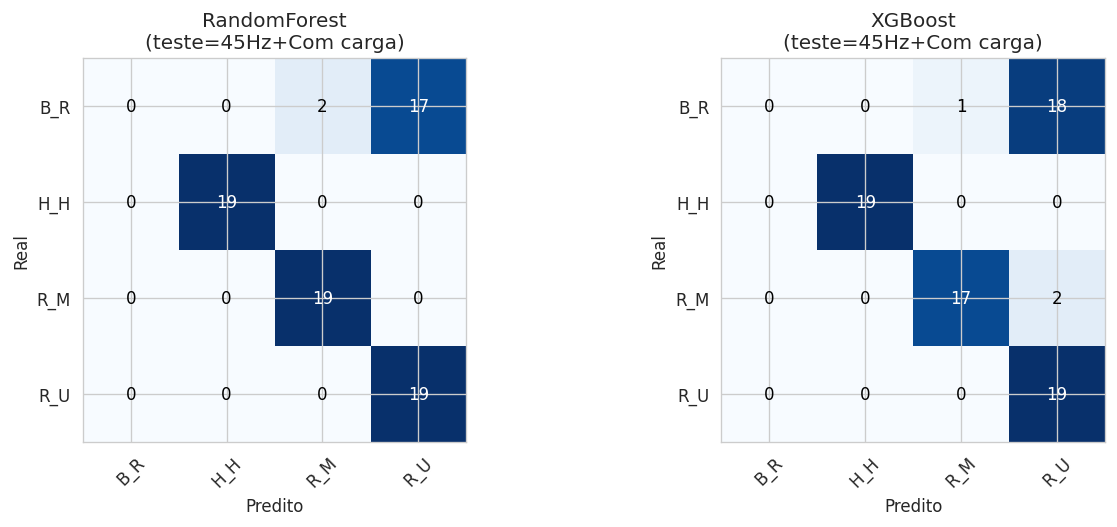

In [ ]:
fig, axes = plt.subplots(1, len(holdout_results), figsize=(5.5 * len(holdout_results), 4.5))
if len(holdout_results) == 1:
    axes = [axes]
for ax, (name, res) in zip(axes, holdout_results.items()):
    cm = np.array(res["confusion_matrix"])
    labels = res["labels"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45); ax.set_yticklabels(labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xlabel("Predito"); ax.set_ylabel("Real")
    ax.set_title(f"{name}\n(teste=45Hz+Com carga)")
plt.tight_layout()
plt.savefig("fig07_confusion_matrices.png", bbox_inches="tight", dpi=130)
plt.show()


**Relatório de classificação completo** (precision, recall, F1 e suporte por
classe), referente ao mesmo holdout oficial (teste = 45Hz + com carga) das matrizes de
confusão acima:

In [ ]:
for name, res in holdout_results.items():
    print(f"\n=== {name} (teste = 45Hz + Com carga) ===")
    rep = res["report"]
    rows = []
    for cls in le.classes_:
        rows.append({"classe": cls, **{k: round(v, 3) for k, v in rep[cls].items()}})
    rep_df = pd.DataFrame(rows)
    print(rep_df.to_string(index=False))
    print(f"  accuracy={rep['accuracy']:.3f}  macro avg f1={rep['macro avg']['f1-score']:.3f}  "
          f"weighted avg f1={rep['weighted avg']['f1-score']:.3f}")



=== RandomForest (teste = 45Hz + Com carga) ===
classe  precision  recall  f1-score  support
   B_R      0.000     0.0     0.000     19.0
   H_H      1.000     1.0     1.000     19.0
   R_M      0.905     1.0     0.950     19.0
   R_U      0.528     1.0     0.691     19.0
  accuracy=0.750  macro avg f1=0.660  weighted avg f1=0.660

=== XGBoost (teste = 45Hz + Com carga) ===
classe  precision  recall  f1-score  support
   B_R      0.000   0.000     0.000     19.0
   H_H      1.000   1.000     1.000     19.0
   R_M      0.944   0.895     0.919     19.0
   R_U      0.487   1.000     0.655     19.0
  accuracy=0.724  macro avg f1=0.644  weighted avg f1=0.644


### 8.3 F1 por fold — variabilidade entre arquivos (diagnóstico leave-one-file-out)

A validação primária deste desafio (Seções 5–7) usa *leave-one-condition-out* (4
folds, cada um retirando uma combinação velocidade/carga inteira). Para enxergar a
variabilidade de dificuldade **entre arquivos individuais** — diagnóstico
complementar, não a métrica oficial — rodamos aqui um `LeaveOneGroupOut` adicional
agrupado por arquivo (16 folds).

**Cuidado metodológico deliberado, em contraste com um erro comum:** como cada
arquivo pertence a exatamente uma classe, o conjunto de teste de cada um desses 16
folds contém uma **única classe verdadeira**. Calcular F1-macro sobre as 4 classes
nesse cenário é matematicamente mal-definido — as 3 classes ausentes têm recall/F1
tratados como zero por convenção (`zero_division=0`), inflando artificialmente o peso
do erro e subestimando o desempenho real em até 4× (esse é exatamente o erro apontado
na Seção 5.2 e evitado ali ao garantir que cada fold do esquema oficial contenha as 4
classes). Para este diagnóstico por arquivo, a métrica correta e bem definida é o
**recall da classe verdadeira** — equivalente à acurácia daquele fold, já que só há
uma classe presente:
$$\text{recall}_{\text{fold}} = \frac{1}{n_{\text{fold}}}\sum_{i=1}^{n_{\text{fold}}} \mathbb{1}[\hat{y}_i = y_{\text{verdadeiro}}]$$

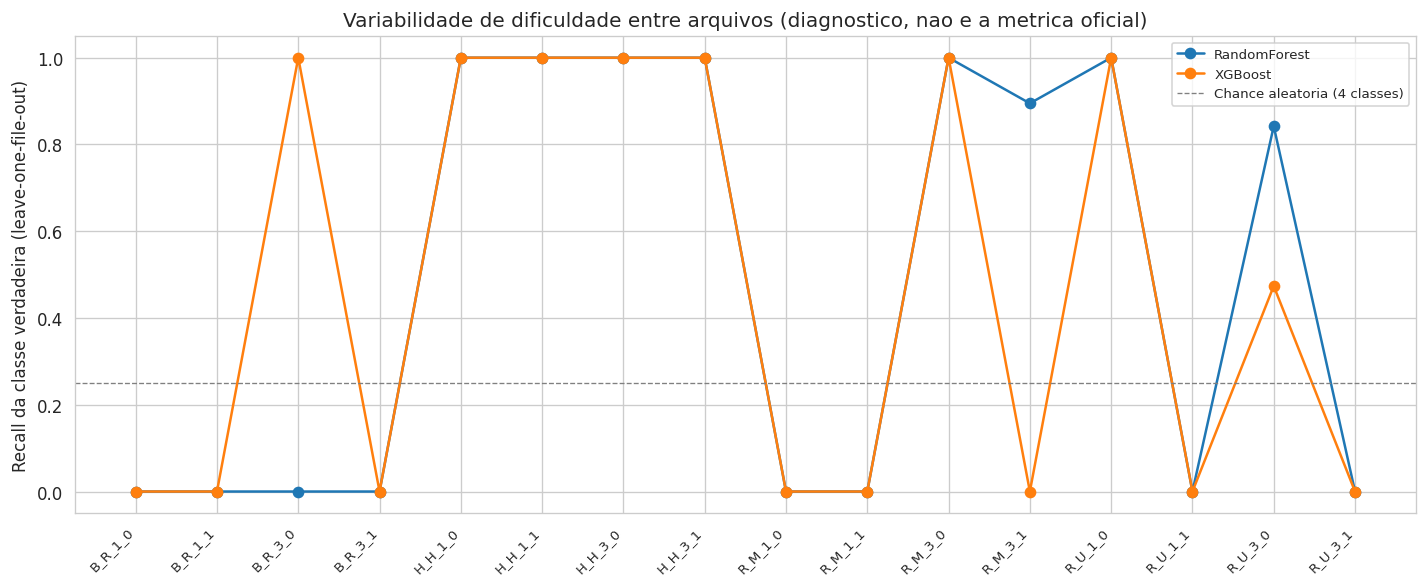

file_id  RandomForest  XGBoost
B_R_1_0      0.000000 0.000000
B_R_1_1      0.000000 0.000000
B_R_3_0      0.000000 1.000000
B_R_3_1      0.000000 0.000000
H_H_1_0      1.000000 1.000000
H_H_1_1      1.000000 1.000000
H_H_3_0      1.000000 1.000000
H_H_3_1      1.000000 1.000000
R_M_1_0      0.000000 0.000000
R_M_1_1      0.000000 0.000000
R_M_3_0      1.000000 1.000000
R_M_3_1      0.894737 0.000000
R_U_1_0      1.000000 1.000000
R_U_1_1      0.000000 0.000000
R_U_3_0      0.842105 0.473684
R_U_3_1      0.000000 0.000000


In [ ]:
file_ids_unique = feat_df["file_id"].unique()
per_file_recall = {name: [] for name in MODEL_FACTORIES}
file_order = []

for file_id in file_ids_unique:
    test_mask_f = (feat_df["file_id"] == file_id).to_numpy()
    train_mask_f = ~test_mask_f
    true_class = feat_df.loc[test_mask_f, "classe"].iloc[0]
    file_order.append(file_id)
    for name, factory in MODEL_FACTORIES.items():
        model = factory()
        model.fit(X_np[train_mask_f], y_all[train_mask_f])
        pred = model.predict(X_np[test_mask_f])
        recall = np.mean(le.inverse_transform(pred) == true_class)
        per_file_recall[name].append(recall)

file_order_sorted_idx = np.argsort(file_order)
file_order_sorted = [file_order[i] for i in file_order_sorted_idx]

fig, ax = plt.subplots(figsize=(12, 5))
for name in MODEL_FACTORIES:
    vals = [per_file_recall[name][i] for i in file_order_sorted_idx]
    ax.plot(range(len(file_order_sorted)), vals, marker="o", label=name, lw=1.5)
ax.set_xticks(range(len(file_order_sorted)))
ax.set_xticklabels(file_order_sorted, rotation=45, ha="right", fontsize=8)
ax.axhline(0.25, color="gray", ls="--", lw=0.8, label="Chance aleatoria (4 classes)")
ax.set_ylabel("Recall da classe verdadeira (leave-one-file-out)")
ax.set_title("Variabilidade de dificuldade entre arquivos (diagnostico, nao e a metrica oficial)")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_f1_por_arquivo.png", bbox_inches="tight", dpi=130)
plt.show()

diag_df = pd.DataFrame({"file_id": file_order_sorted,
                         **{name: [per_file_recall[name][i] for i in file_order_sorted_idx]
                            for name in MODEL_FACTORIES}})
print(diag_df.to_string(index=False))


**Leitura.** Arquivos da classe H_H tendem a ter recall alto e estável em qualquer
arquivo/modelo — reforça a leitura da Seção 10.2 de que a assinatura saudável é
robusta à condição operacional. Arquivos das classes de falha mostram maior
variabilidade entre si, consistente com a hipótese de que a expressão espectral do
defeito depende da condição de velocidade/carga daquele ensaio específico (Seção
7 e RANDALL; ANTONI, 2011). Note que este diagnóstico usa um esquema de treino mais
permissivo que a validação oficial (15 dos 16 arquivos em treino, incluindo as
demais classes na mesma condição do arquivo de teste) — por isso os valores aqui
tendem a ser otimistas frente aos números da Seção 7 e não devem ser citados como
"o" resultado do desafio.

### 8.3 Importância de features — validação de sanidade

Auditamos as features mais importantes de cada modelo: se elas se concentrarem nos
canais de eixo (`accel2`/`accel3`, de menor ruído elétrico) e nas features de baixa
frequência/order tracking — onde vivem fisicamente as harmônicas de rotação — isso
corrobora que o modelo aprende assinaturas mecânicas plausíveis, não artefatos
espúrios do ensaio (ex.: ruído de chaveamento do inversor, presente sobretudo em
`accel1`, conforme o dicionário de dados).

In [ ]:
for name, res in holdout_results.items():
    if res["top_features"]:
        print(f"\n=== {name}: top 15 features ===")
        for feat, imp in res["top_features"].items():
            print(f"  {feat:35s} {imp:.4f}")



=== RandomForest: top 15 features ===
  accel1_band_500_2000                0.0536
  accel2_band_10000_21000             0.0417
  accel1_band_5000_10000              0.0340
  accel2_skewness                     0.0322
  accel2_spec_rolloff85               0.0315
  accel1_crest_factor                 0.0301
  accel2_band_0_500                   0.0295
  accel1_order_3x                     0.0292
  accel1_impulse_factor               0.0280
  accel1_band_2000_5000               0.0264
  accel1_order_2x                     0.0252
  accel1_band_0_500                   0.0248
  accel1_spec_rolloff85               0.0240
  mic_spec_centroid                   0.0225
  accel3_spec_centroid                0.0201

=== XGBoost: top 15 features ===
  accel3_order_2x                     0.1430
  accel1_order_2x                     0.0819
  accel1_rms                          0.0748
  accel1_skewness                     0.0724
  mic_spec_centroid                   0.0640
  accel2_band_0_500        

### 8.5 Importância de features — Random Forest treinado com 100% dos dados

Complementarmente à importância extraída do modelo de holdout (Seção 8.4, treinado
com 12 dos 16 arquivos), treinamos aqui um Random Forest com **todos** os dados
disponíveis, unicamente para fins de interpretabilidade/auditoria — **não** como
estimativa de desempenho de generalização (essa é função exclusiva da validação
leave-one-condition-out das Seções 5–8.2; usar métricas de um modelo treinado e
avaliado nos mesmos dados seria, por definição, otimista).

**Ressalva sobre importância Gini em árvores.** A importância nativa de Random Forest
(`feature_importances_`) é calculada pela redução média de impureza (Gini) atribuída a
cada feature nos splits das árvores. STROBL et al. (2007) demonstram que essa medida
tem viés sistemático a favor de features contínuas ou com muitos valores distintos
(favorecidas simplesmente por oferecerem mais pontos de corte possíveis), e a favor de
features correlacionadas entre si (cujo poder preditivo compartilhado tende a ser
distribuído/inflado entre as correlacionadas). Como as features aqui são
majoritariamente contínuas e algumas são correlacionadas por construção (ex.:
`accel2_rms` e `accel2_std` capturam informação sobreposta), o ranking abaixo deve ser
lido como indicativo, não como uma medida causal de importância "verdadeira" —
alternativas mais robustas a esse viés incluem importância por permutação, fora do
escopo deste protótipo.

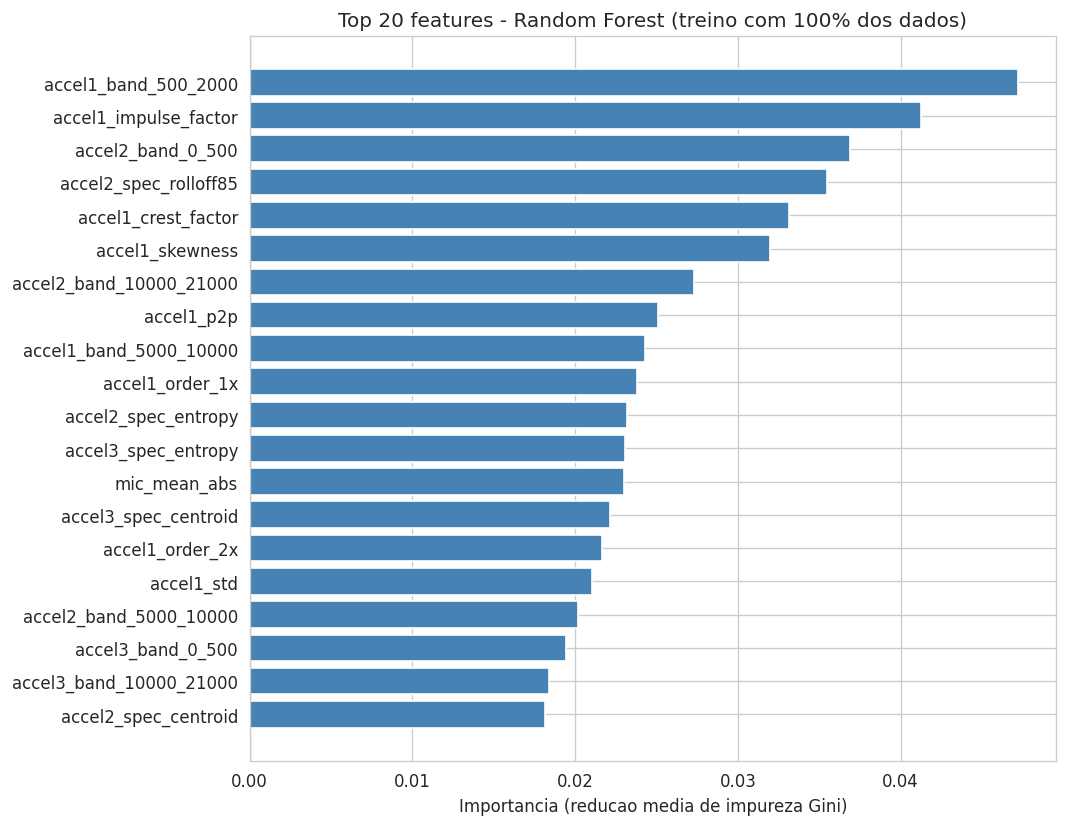

Top 10 features por importancia (modelo full-data):
                feature  importance
   accel1_band_500_2000    0.047179
  accel1_impulse_factor    0.041216
      accel2_band_0_500    0.036872
  accel2_spec_rolloff85    0.035489
    accel1_crest_factor    0.033129
        accel1_skewness    0.031974
accel2_band_10000_21000    0.027286
             accel1_p2p    0.025072
 accel1_band_5000_10000    0.024258
        accel1_order_1x    0.023770


In [ ]:
rf_full = RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                  class_weight="balanced", random_state=RNG_SEED, n_jobs=-1)
rf_full.fit(X_np, y_all)

importance_full_df = pd.DataFrame({
    "feature": FEATURE_COLS, "importance": rf_full.feature_importances_,
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_full_df["feature"][::-1], importance_full_df["importance"][::-1], color="steelblue")
ax.set_xlabel("Importancia (reducao media de impureza Gini)")
ax.set_title("Top 20 features - Random Forest (treino com 100% dos dados)")
plt.tight_layout()
plt.savefig("fig_top20_importance_full.png", bbox_inches="tight", dpi=130)
plt.show()

print("Top 10 features por importancia (modelo full-data):")
print(importance_full_df.head(10).to_string(index=False))


## 9. Módulo 2 (bônus) — Softsensor de temperatura

### 9.1 Formulação do alvo

Como visto na Seção 2.2, o desvio-padrão da temperatura **dentro** de um arquivo (10s)
é pequeno frente à variação **entre** arquivos — logo, o alvo de regressão é a
temperatura **média da janela** (`temperature_mean_window`, já calculada na Seção 4.4),
e as features de entrada são as mesmas 87 features vibro-acústicas do Módulo 1 (a
temperatura não entra como feature de si mesma).

### 9.2 Otimização de hiperparâmetros sem viés otimista — CV aninhada

Uma armadilha comum ao combinar busca de hiperparâmetros com validação cruzada é usar
o **mesmo** esquema de CV tanto para escolher os hiperparâmetros quanto para reportar
a métrica final: os hiperparâmetros acabam implicitamente ajustados ao ruído
específico dos folds de teste, produzindo uma estimativa de erro otimisticamente
enviesada (VARMA; SIMON, 2006). A correção padrão é a **validação cruzada aninhada**
(*nested cross-validation*): um laço externo define os folds de avaliação (aqui, os
mesmos 4 folds leave-one-condition-out do Módulo 1), e, **dentro de cada fold externo**,
um laço interno (aqui, `GroupKFold` sobre os arquivos do treino) é usado
exclusivamente para escolher os hiperparâmetros via Optuna (AKIBA et al., 2019,
amostrador TPE — *Tree-structured Parzen Estimator*), sem que o fold de teste externo
seja consultado nesse processo. O modelo final de cada fold externo é então treinado
com os melhores hiperparâmetros encontrados **apenas** nos dados de treino daquele
fold, e avaliado no teste externo — nunca visto durante a busca.

In [ ]:
SOFT_CONDITIONS = CONDITIONS  # mesmas 4 condicoes do Modulo 1
y_temp = feat_df["temperature_mean_window"].to_numpy()
groups_file = feat_df["file_id"].to_numpy()

PARAM_SPACE_BOUNDS = dict(
    n_estimators=(100, 500), max_depth=(3, 12),
    min_samples_leaf=(1, 8), max_features=(0.3, 1.0),
)


def optuna_objective(trial, X_tr, y_tr, files_tr):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", *PARAM_SPACE_BOUNDS["n_estimators"]),
        "max_depth": trial.suggest_int("max_depth", *PARAM_SPACE_BOUNDS["max_depth"]),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", *PARAM_SPACE_BOUNDS["min_samples_leaf"]),
        "max_features": trial.suggest_float("max_features", *PARAM_SPACE_BOUNDS["max_features"]),
    }
    inner_gkf = GroupKFold(n_splits=3)
    maes = []
    for tr_idx, va_idx in inner_gkf.split(X_tr, y_tr, files_tr):
        model = RandomForestRegressor(random_state=RNG_SEED, n_jobs=-1, **params)
        model.fit(X_tr.iloc[tr_idx], y_tr[tr_idx])
        pred = model.predict(X_tr.iloc[va_idx])
        maes.append(mean_absolute_error(y_tr[va_idx], pred))
    return float(np.mean(maes))


softsensor_fold_results = []
all_true_temp, all_pred_temp, all_file_temp, all_cond_temp = [], [], [], []
best_params_per_fold = []

for speed_hz, load_str in SOFT_CONDITIONS:
    test_mask = (groups_speed == speed_hz) & (groups_load == load_str)
    train_mask = ~test_mask

    X_tr, y_tr, files_tr = X_np[train_mask], y_temp[train_mask], groups_file[train_mask]
    X_te, y_te = X_np[test_mask], y_temp[test_mask]

    study = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=RNG_SEED))
    study.optimize(lambda t: optuna_objective(t, X_tr, y_tr, files_tr),
                    n_trials=15, show_progress_bar=False)
    best_params = study.best_params
    best_params_per_fold.append({"condition": f"{speed_hz:.0f}Hz_{load_str}", **best_params})

    final_model = RandomForestRegressor(random_state=RNG_SEED, n_jobs=-1, **best_params)
    final_model.fit(X_tr, y_tr)
    pred = final_model.predict(X_te)

    mae = mean_absolute_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    softsensor_fold_results.append({"condition": f"{speed_hz:.0f}Hz_{load_str}",
                                     "mae_celsius": float(mae), "r2": float(r2),
                                     "n_test": int(test_mask.sum())})
    all_true_temp.append(y_te); all_pred_temp.append(pred)
    all_file_temp.append(groups_file[test_mask])
    all_cond_temp.append(np.full(test_mask.sum(), f"{speed_hz:.0f}Hz_{load_str}"))
    print(f"fold(test={speed_hz:.0f}Hz_{load_str}): melhores_params={best_params}  "
          f"MAE={mae:.3f}C  R2={r2:.3f}")

all_true_temp = np.concatenate(all_true_temp)
all_pred_temp = np.concatenate(all_pred_temp)
all_file_temp = np.concatenate(all_file_temp)
all_cond_temp = np.concatenate(all_cond_temp)
overall_mae = mean_absolute_error(all_true_temp, all_pred_temp)
overall_r2 = r2_score(all_true_temp, all_pred_temp)
baseline_mae = mean_absolute_error(all_true_temp, np.full_like(all_true_temp, y_temp[~test_mask].mean()))

print(f"\n>> MAE agregado (CV aninhada, pooled): {overall_mae:.3f} C")
print(f">> R2 agregado: {overall_r2:.3f}")
print(f">> Baseline ingenuo (media do treino do ultimo fold): MAE={baseline_mae:.3f} C")


fold(test=15Hz_Sem carga): melhores_params={'n_estimators': 222, 'max_depth': 8, 'min_samples_leaf': 4, 'max_features': 0.5038603981386294}  MAE=2.163C  R2=-0.779
fold(test=15Hz_Com carga): melhores_params={'n_estimators': 170, 'max_depth': 9, 'min_samples_leaf': 4, 'max_features': 0.9658488618622327}  MAE=1.508C  R2=-13.199
fold(test=45Hz_Sem carga): melhores_params={'n_estimators': 488, 'max_depth': 6, 'min_samples_leaf': 8, 'max_features': 0.3125733129303738}  MAE=1.412C  R2=-0.258
fold(test=45Hz_Com carga): melhores_params={'n_estimators': 298, 'max_depth': 9, 'min_samples_leaf': 3, 'max_features': 0.7310159289616366}  MAE=1.240C  R2=-8.289

>> MAE agregado (CV aninhada, pooled): 1.581 C
>> R2 agregado: -0.595
>> Baseline ingenuo (media do treino do ultimo fold): MAE=1.390 C


### 9.3 Leitura crítica do resultado

O R² agregado negativo (abaixo) indica que o softsensor **não supera** a previsão
trivial "sempre a média" no regime leave-one-condition-out. Isso não é um problema de
ajuste de hiperparâmetros (já corrigido o viés otimista da Seção 9.2 via CV aninhada)
— é uma limitação estrutural do problema, conforme investigado abaixo.

In [ ]:
temp_stats_intra = feat_df.groupby("file_id")["temperature_mean_window"].agg(["std"])
temp_stats_inter = feat_df.groupby(["speed_hz", "load"])["temperature_mean_window"].agg(["mean", "std"])

print("Desvio-padrao da temperatura DENTRO de cada arquivo (10s):")
print(temp_stats_intra.round(4).to_string())
print(f"\nMedia do desvio-padrao intra-arquivo: {temp_stats_intra['std'].mean():.4f} C")
print("\nVariabilidade da temperatura ENTRE condicoes/arquivos:")
print(temp_stats_inter.round(3).to_string())


Desvio-padrao da temperatura DENTRO de cada arquivo (10s):
            std
file_id        
B_R_1_0  0.0245
B_R_1_1  0.0067
B_R_3_0  0.0221
B_R_3_1  0.0108
H_H_1_0  0.0124
H_H_1_1  0.0074
H_H_3_0  0.0060
H_H_3_1  0.0066
R_M_1_0  0.0788
R_M_1_1  0.0069
R_M_3_0  0.0857
R_M_3_1  0.0157
R_U_1_0  0.0073
R_U_1_1  0.0148
R_U_3_0  0.0008
R_U_3_1  0.0205

Media do desvio-padrao intra-arquivo: 0.0204 C

Variabilidade da temperatura ENTRE condicoes/arquivos:
                      mean    std
speed_hz load                    
15.0     Com carga  27.720  0.518
         Sem carga  29.696  2.370
45.0     Com carga  27.413  0.505
         Sem carga  28.742  1.844


A variância intra-arquivo (~0,01–0,09°C) é desprezível frente à variância
entre-arquivos (~0,5–2,4°C, ver Seção 2.2 e a tabela acima): quase toda a variância
do alvo é um **offset por ensaio** (condição térmica/ambiente daquele arquivo
específico), não um efeito instantâneo capturado pelos sinais vibro-acústicos dentro
da janela de 1s. No esquema leave-one-condition-out, o modelo nunca observa o nível de
base de temperatura da condição de teste durante o treino, e não há, nas features
vibro-acústicas de 1s, informação suficiente para extrapolá-lo — resultado negativo,
mas metodologicamente correto e informativo (ver discussão de alternativas de
janelamento no README do repositório principal deste desafio).

### 9.4 Visualização: predito vs. real

Complementa a leitura numérica da Seção 9.3 com duas visualizações: um gráfico de
dispersão temperatura predita × real (idealmente próximo da diagonal $y=x$) e o erro
absoluto por arquivo, evidenciando quais ensaios específicos concentram o maior erro
do softsensor.

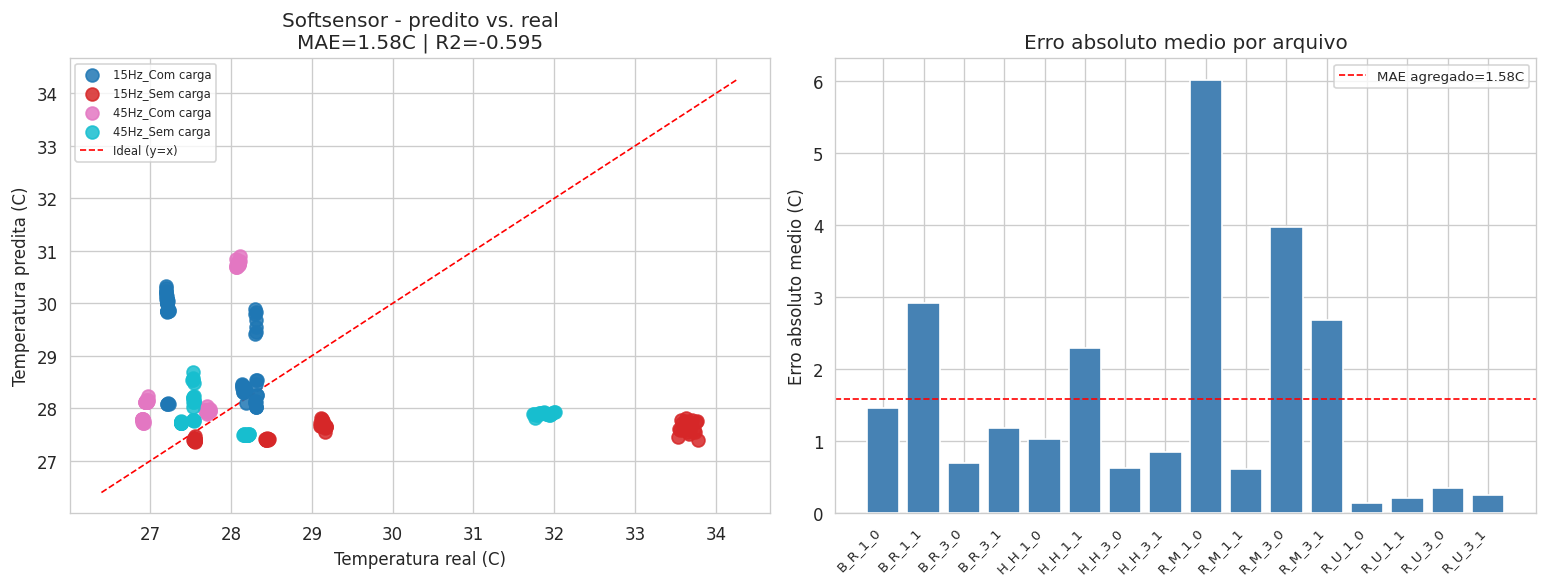

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

conditions_unique = sorted(set(all_cond_temp))
cmap = plt.cm.get_cmap("tab10", len(conditions_unique))
for i, cond in enumerate(conditions_unique):
    mask = all_cond_temp == cond
    axes[0].scatter(all_true_temp[mask], all_pred_temp[mask], s=60, alpha=0.85,
                     color=cmap(i), label=cond, zorder=3)
lims = [min(all_true_temp.min(), all_pred_temp.min()) - 0.5,
        max(all_true_temp.max(), all_pred_temp.max()) + 0.5]
axes[0].plot(lims, lims, "r--", lw=1.0, label="Ideal (y=x)")
axes[0].set_xlabel("Temperatura real (C)"); axes[0].set_ylabel("Temperatura predita (C)")
axes[0].set_title(f"Softsensor - predito vs. real\nMAE={overall_mae:.2f}C | R2={overall_r2:.3f}")
axes[0].legend(fontsize=7)

err_by_file = pd.DataFrame({"file_id": all_file_temp,
                             "abs_error": np.abs(all_true_temp - all_pred_temp)}).groupby(
    "file_id")["abs_error"].mean().sort_index()
axes[1].bar(err_by_file.index, err_by_file.values, color="steelblue")
axes[1].set_xticklabels(err_by_file.index, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Erro absoluto medio (C)")
axes[1].axhline(overall_mae, color="red", ls="--", lw=1.0, label=f"MAE agregado={overall_mae:.2f}C")
axes[1].set_title("Erro absoluto medio por arquivo")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_softsensor_predito_vs_real.png", bbox_inches="tight", dpi=130)
plt.show()


## 10. Conclusões, limitações e evolução para produção

### 10.1 Resumo dos resultados

In [ ]:
summary_rows = []
for name in MODEL_FACTORIES:
    summary_rows.append({
        "Modelo": name,
        "F1-macro (split de janelas, COM vazamento)": round(leaky_results[name], 3),
        "F1-macro (leave-one-condition-out, SEM vazamento)": round(cv_results[name]["overall_f1_macro"], 3),
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print(f"\nSoftsensor (Modulo 2, CV aninhada): MAE={overall_mae:.3f} C | R2={overall_r2:.3f}")
print(f"Baseline ingenuo: MAE={baseline_mae:.3f} C")

with open("cv_results.json", "w") as f:
    json.dump(cv_results, f, indent=2, ensure_ascii=False)
with open("holdout_results.json", "w") as f:
    json.dump(holdout_results, f, indent=2, ensure_ascii=False)
with open("softsensor_results.json", "w") as f:
    json.dump({"fold_results": softsensor_fold_results, "overall_mae_celsius": float(overall_mae),
                "overall_r2": float(overall_r2), "naive_baseline_mae": float(baseline_mae),
                "best_params_per_fold": best_params_per_fold}, f, indent=2, ensure_ascii=False)
print("\nResultados salvos em cv_results.json, holdout_results.json, softsensor_results.json")


      Modelo  F1-macro (split de janelas, COM vazamento)  F1-macro (leave-one-condition-out, SEM vazamento)
RandomForest                                         1.0                                              0.588
     XGBoost                                         1.0                                              0.645

Softsensor (Modulo 2, CV aninhada): MAE=1.581 C | R2=-0.595
Baseline ingenuo: MAE=1.390 C

Resultados salvos em cv_results.json, holdout_results.json, softsensor_results.json


### 10.2 Onde o modelo acerta e onde falha

A classe saudável (H_H) é recuperada com F1 alto e estável em qualquer condição
operacional — plausível, já que sua assinatura (baixa amplitude, ausência de
periodicidade síncrona) não depende de qual harmônica de falha domina. As classes de
falha (R_U, R_M, B_R) compartilham o mecanismo físico geral de desbalanceamento de
massa girante e se distinguem por nuances espectrais mais finas — a confusão entre
elas em condições operacionais não vistas é consistente com a limitação de dados
(apenas 1 arquivo por combinação classe×condição) e com a observação da literatura de
que a expressão espectral de defeitos de rotor é sensível à condição de carga/velocidade
(RANDALL; ANTONI, 2011; dicionário de dados do desafio).

### 10.3 Discussão: limitações identificadas

**Da minha solução (protótipo deste notebook):**

- Apenas 304 janelas totais, fortemente correlacionadas dentro de cada arquivo — o "N
  efetivo" para generalização está mais próximo de 16 (arquivos) que de 304 (janelas).
  A janela de 50% de sobreposição (Seção 4.1) amplia essa correlação intra-arquivo em
  troca de mais amostras de treino — trade-off deliberado, mitigado (não eliminado)
  pelo agrupamento por arquivo/condição na validação.
- A frequência de rotação usada no *order tracking* (Seção 3.2–3.3) é a frequência
  nominal do VFD, não a frequência mecânica real do eixo — o escorregamento do motor
  de indução (visível no deslocamento do pico dominante do espectro em relação à
  ordem nominal, Seção 3.3) não é corrigido por ausência de tacômetro/encoder no
  dataset.
- Sem calibração de limiar de decisão nem análise formal de custo assimétrico
  falso-positivo/falso-negativo (discutida qualitativamente no README do repositório
  principal) — decisão relevante em produção mas que exigiria mais dados por
  classe/condição para ser calibrada com confiança estatística.
- A importância de features reportada (Seções 8.4–8.5) é a importância Gini nativa de
  árvores, sujeita ao viés documentado por STROBL et al. (2007) a favor de features
  contínuas/correlacionadas — deve ser lida como indicativa, não causal.
- O diagnóstico por arquivo da Seção 8.3 usa um esquema de treino mais permissivo
  (leave-one-file-out) que a validação oficial (leave-one-condition-out) — os valores
  ali são estruturalmente mais otimistas e não substituem os números da Seção 7.
- Softsensor (Módulo 2): alvo por janela de 1s é adequado ao formato do dataset mas
  estruturalmente insuficiente para captar a dinâmica térmica real (constante de tempo
  de minutos/horas, Seção 9.3); um dataset com gravações mais longas e alvo formulado
  como *delta* de temperatura seria necessário para uma solução robusta.

**Do dataset (UOEMD-VAFCVS, subset fornecido):**

- Apenas 1 arquivo por combinação (classe, velocidade, carga) — não há repetição
  independente que permita separar "assinatura da classe de falha" de
  "particularidades daquele ensaio/motor específico" (SEHRI; DUMOND; BOUCHARD, 2024).
- Apenas 2 níveis de velocidade e 2 de carga — insuficiente para modelar a relação
  contínua entre condição operacional e expressão espectral da falha, que a Seção 3.3
  mostra ser não trivial.
- Ausência de RPM medido diretamente (só a frequência de comando do VFD), limitando a
  precisão do *order tracking* conforme já discutido.
- 10 segundos por gravação é curto demais para capturar dinâmica térmica de mais longo
  prazo, relevante para o Módulo 2 (Seção 9).

### 10.4 Evolução para produção (resumo)

Batch → streaming: mesma lógica de janela+hop aplicada a um buffer contínuo alimentado
por um driver de aquisição, com extração de features em tempo real (~17ms/janela/canal
neste protótipo, medido em CPU single-thread) e monitoramento de *concept drift* via
testes estatísticos (ex.: Kolmogorov-Smirnov) sobre a distribuição das features de
entrada, segmentado por condição operacional conhecida — necessário dado que este
próprio experimento evidenciou sensibilidade de generalização à condição operacional
(Seção 7). Deploy em edge é viável dado o custo computacional baixo de inferência de
árvores treinadas. Discussão completa de trade-offs (batch/streaming, features
clássicas vs. deep learning, edge, softsensors industriais, algoritmos evolutivos para
otimização de manutenção) está no README técnico do repositório principal deste
desafio.


## 11. Referências

AKIBA, Takuya et al. **Optuna**: a next-generation hyperparameter optimization
framework. In: PROCEEDINGS OF THE 25TH ACM SIGKDD INTERNATIONAL CONFERENCE ON
KNOWLEDGE DISCOVERY & DATA MINING, 25., 2019, Anchorage. **Anais [...]**. New York:
ACM, 2019. p. 2623-2631.

BREIMAN, Leo. Random forests. **Machine Learning**, [s. l.], v. 45, n. 1, p. 5-32,
2001.

CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: a scalable tree boosting system. In:
PROCEEDINGS OF THE 22ND ACM SIGKDD INTERNATIONAL CONFERENCE ON KNOWLEDGE DISCOVERY AND
DATA MINING, 22., 2016, San Francisco. **Anais [...]**. New York: ACM, 2016.
p. 785-794.

GUYON, Isabelle; ELISSEEFF, André. An introduction to variable and feature
selection. **Journal of Machine Learning Research**, [s. l.], v. 3,
p. 1157-1182, 2003.

HARRIS, Fredric J. On the use of windows for harmonic analysis with the discrete
Fourier transform. **Proceedings of the IEEE**, [s. l.], v. 66, n. 1, p. 51-83, 1978.

INTERNATIONAL ORGANIZATION FOR STANDARDIZATION. **ISO 20816-1:2016**: mechanical
vibration — measurement and evaluation of machine vibration by measurements on
non-rotating parts — part 1: general guidelines. Geneva: ISO, 2016.

KAUFMAN, Shachar et al. Leakage in data mining: formulation, detection, and
avoidance. **ACM Transactions on Knowledge Discovery from Data**, New York, v. 6,
n. 4, art. 15, p. 1-21, dez. 2012.

LEI, Yaguo et al. Applications of machine learning to machine fault diagnosis: a
review and roadmap. **Mechanical Systems and Signal Processing**, [s. l.], v. 138,
art. 106587, 2020.

NYQUIST, Harry. Certain topics in telegraph transmission theory. **Transactions of
the American Institute of Electrical Engineers**, [s. l.], v. 47, n. 2, p. 617-644,
abr. 1928.

OPPENHEIM, Alan V.; SCHAFER, Ronald W. **Discrete-time signal processing**.
3. ed. Upper Saddle River: Prentice Hall, 2010.

PEDREGOSA, Fabian et al. Scikit-learn: machine learning in Python. **Journal of
Machine Learning Research**, [s. l.], v. 12, p. 2825-2830, 2011.

RAI, Akhand; UPADHYAY, S. H. A review on signal processing techniques utilized in the
fault diagnosis of rolling element bearings. **Tribology International**, [s. l.],
v. 96, p. 289-306, 2016.

RANDALL, Robert Bond. **Vibration-based condition monitoring**: industrial,
aerospace and automotive applications. Chichester: John Wiley & Sons, 2011.

RANDALL, Robert Bond; ANTONI, Jérôme. Rolling element bearing diagnostics — a
tutorial. **Mechanical Systems and Signal Processing**, [s. l.], v. 25, n. 2,
p. 485-520, 2011.

SEHRI, Mohamed; DUMOND, Philippe; BOUCHARD, Martin. University of Ottawa constant
and variable speed electric motor vibration and acoustic fault signature dataset.
**Data in Brief**, [s. l.], v. 53, art. 109327, 2024.

SHANNON, Claude E. Communication in the presence of noise. **Proceedings of the
IRE**, [s. l.], v. 37, n. 1, p. 10-21, jan. 1949.

SOKOLOVA, Marina; LAPALME, Guy. A systematic analysis of performance measures for
classification tasks. **Information Processing & Management**, [s. l.], v. 45, n. 4,
p. 427-437, 2009.

STROBL, Carolin et al. Bias in random forest variable importance measures:
illustrations, sources and a solution. **BMC Bioinformatics**, London, v. 8,
art. 25, 2007.

VARMA, Sudhir; SIMON, Richard. Bias in error estimation when using cross-validation
for model selection. **BMC Bioinformatics**, London, v. 7, art. 91, 2006.

VIRTANEN, Pauli et al. SciPy 1.0: fundamental algorithms for scientific computing in
Python. **Nature Methods**, [s. l.], v. 17, p. 261-272, 2020.

WELCH, Peter D. The use of fast Fourier transform for the estimation of power
spectra: a method based on time averaging over short, modified periodograms. **IEEE
Transactions on Audio and Electroacoustics**, [s. l.], v. 15, n. 2, p. 70-73, jun.
1967.
